In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

# I want to load the csv files hera gave me and then prepare a format that would work in the machine learning model

In [2]:

# simulation_gmm_results = pd.read_csv('/lustre/fs8/risc_lab/scratch/rjohnson/pipelines/machine_learning_project/simulation_GMM_results/simulation_GMM_params 1.csv')

# print(simulation_gmm_results)

                     sample_name  component  mu_bp  sigma_bp  amplitude_A  \
0     NRL165_12nucs_2kbt_trial_1          1   78.7      15.6     883.6970   
1     NRL165_12nucs_2kbt_trial_1          2  162.2      27.9      74.0099   
2     NRL165_12nucs_2kbt_trial_1          3  254.5      22.8     117.5100   
3     NRL165_12nucs_2kbt_trial_1          4  331.3      26.2     160.3863   
4     NRL165_12nucs_2kbt_trial_1          5  411.6      18.6     104.8284   
..                           ...        ...    ...       ...          ...   
122  NRL215_12nucs_2kbt_trial_10          4  418.6      14.7      16.5372   
123   NRL215_12nucs_2kbt_trial_3          1   79.2      17.2     952.5304   
124   NRL215_12nucs_2kbt_trial_3          2  165.0      25.1      74.6341   
125   NRL215_12nucs_2kbt_trial_3          3  341.6       9.2       3.9131   
126   NRL215_12nucs_2kbt_trial_3          4  419.5      15.2      17.9716   

     rel_amplitude  baseline_C  fit_r2  fit_residual_frac  fit_area_recover

In [2]:

# simulation_gmm_results = pd.read_csv('/lustre/fs8/risc_lab/scratch/rjohnson/pipelines/machine_learning_project/simulation_GMM_results/full_simulation_GMM_params.csv')

simulation_gmm_results = pd.read_csv('/lustre/fs8/risc_lab/scratch/rjohnson/pipelines/machine_learning_project/simulation_GMM_results/2026_9_24_simulation_GMM_params.csv')

print(simulation_gmm_results)

                     sample_name  component  mu_bp  sigma_bp  amplitude_A  \
0     NRL165_12nucs_2kbt_trial_1          1   78.7      15.6     883.6970   
1     NRL165_12nucs_2kbt_trial_1          2  162.2      27.9      74.0099   
2     NRL165_12nucs_2kbt_trial_1          3  254.5      22.8     117.5100   
3     NRL165_12nucs_2kbt_trial_1          4  331.3      26.2     160.3863   
4     NRL165_12nucs_2kbt_trial_1          5  411.6      18.6     104.8284   
...                          ...        ...    ...       ...          ...   
3431  NRL215_12nucs_2kbt_trial_8          4  418.3      14.2      15.5072   
3432  NRL215_12nucs_2kbt_trial_9          1   79.2      17.2     952.9844   
3433  NRL215_12nucs_2kbt_trial_9          2  167.0      26.8      75.6636   
3434  NRL215_12nucs_2kbt_trial_9          3  339.1       8.3       4.0835   
3435  NRL215_12nucs_2kbt_trial_9          4  420.9      15.8      21.4589   

      rel_amplitude  baseline_C  fit_r2  fit_residual_frac  fit_area_recove

In [19]:
?str.split

Signature: str.split(self, /, sep=None, maxsplit=-1)
Docstring:
Return a list of the substrings in the string, using sep as the separator string.

  sep
    The separator used to split the string.

    When set to None (the default value), will split on any
    whitespace character (including \n \r \t \f and spaces) and
    will discard empty strings from the result.
  maxsplit
    Maximum number of splits.
    -1 (the default value) means no limit.

Splitting starts at the front of the string and works to the end.

Note, str.split() is mainly useful for data that has been
intentionally delimited.  With natural text that includes
punctuation, consider using the regular expression module.
Type:      method_descriptor

In [3]:
simulation_gmm_results

# now I want to make each same trial exist on the same row
# so the components are actually the peak number for the same trial
# i want to have 5 columns for the mu which represents the five peaks in a given trial

,sample_name,component,mu_bp,sigma_bp,amplitude_A,rel_amplitude,baseline_C,fit_r2,fit_residual_frac,fit_area_recovery,fit_baseline
0,NRL165_12nucs_2kbt_trial_1,1,78.7,15.6,883.6970,0.6593,85.4226,0.9895,0.0210,1.0007,85.4226
1,NRL165_12nucs_2kbt_trial_1,2,162.2,27.9,74.0099,0.0552,85.4226,0.9895,0.0210,1.0007,85.4226
2,NRL165_12nucs_2kbt_trial_1,3,254.5,22.8,117.5100,0.0877,85.4226,0.9895,0.0210,1.0007,85.4226
3,NRL165_12nucs_2kbt_trial_1,4,331.3,26.2,160.3863,0.1197,85.4226,0.9895,0.0210,1.0007,85.4226
4,NRL165_12nucs_2kbt_trial_1,5,411.6,18.6,104.8284,0.0782,85.4226,0.9895,0.0210,1.0007,85.4226
...,...,...,...,...,...,...,...,...,...,...,...
3431,NRL215_12nucs_2kbt_trial_8,4,418.3,14.2,15.5072,0.0147,57.5327,0.9885,0.0449,1.0009,57.5327
3432,NRL215_12nucs_2kbt_trial_9,1,79.2,17.2,952.9844,0.9040,59.4991,0.9887,0.0430,1.0009,59.4991
3433,NRL215_12nucs_2kbt_trial_9,2,167.0,26.8,75.6636,0.0718,59.4991,0.9887,0.0430,1.0009,59.4991
3434,NRL215_12nucs_2kbt_trial_9,3,339.1,8.3,4.0835,0.0039,59.4991,0.9887,0.0430,1.0009,59.4991


In [4]:
# drop one of the trials before pivoting

# simulation_gmm_drop_rep = simulation_gmm_results[simulation_gmm_results['sample_name'] != 'NRL167_12nucs_2kbt_trial_10' ]

# just to note though, some peaks that are called by the gmm (gaussian) do not get to 5 peaks.
# so I just need to make sure all of the peaks are actually called on a peak and not a trough. 
# just checked and they all look good. there is one sample that only gets 3 peaks being called

# i need to drop the 215 nrl's that are labeled chunk only keep the trials

# simulation_gmm_drop_rep = simulation_gmm_drop_rep[~simulation_gmm_drop_rep['sample_name'].str.contains('chunk')]

# simulation_gmm_drop_rep


,sample_name,component,mu_bp,sigma_bp,amplitude_A,rel_amplitude,baseline_C,fit_r2,fit_residual_frac,fit_area_recovery,fit_baseline
0,NRL165_12nucs_2kbt_trial_1,1,78.7,15.6,883.6970,0.6593,85.4226,0.9895,0.0210,1.0007,85.4226
1,NRL165_12nucs_2kbt_trial_1,2,162.2,27.9,74.0099,0.0552,85.4226,0.9895,0.0210,1.0007,85.4226
2,NRL165_12nucs_2kbt_trial_1,3,254.5,22.8,117.5100,0.0877,85.4226,0.9895,0.0210,1.0007,85.4226
3,NRL165_12nucs_2kbt_trial_1,4,331.3,26.2,160.3863,0.1197,85.4226,0.9895,0.0210,1.0007,85.4226
4,NRL165_12nucs_2kbt_trial_1,5,411.6,18.6,104.8284,0.0782,85.4226,0.9895,0.0210,1.0007,85.4226
...,...,...,...,...,...,...,...,...,...,...,...
3431,NRL215_12nucs_2kbt_trial_8,4,418.3,14.2,15.5072,0.0147,57.5327,0.9885,0.0449,1.0009,57.5327
3432,NRL215_12nucs_2kbt_trial_9,1,79.2,17.2,952.9844,0.9040,59.4991,0.9887,0.0430,1.0009,59.4991
3433,NRL215_12nucs_2kbt_trial_9,2,167.0,26.8,75.6636,0.0718,59.4991,0.9887,0.0430,1.0009,59.4991
3434,NRL215_12nucs_2kbt_trial_9,3,339.1,8.3,4.0835,0.0039,59.4991,0.9887,0.0430,1.0009,59.4991


In [3]:
# test

# df_wide = simulation_gmm_drop_rep.pivot(index='sample_name', columns='component')

df_wide = simulation_gmm_results.pivot(index='sample_name', columns='component')

df_wide

mu_bp                             sigma_bp        \
component                       1      2      3      4      5        1     2   
sample_name                                                                    
NRL165_12nucs_2kbt_trial_1   78.7  162.2  254.5  331.3  411.6     15.6  27.9   
NRL165_12nucs_2kbt_trial_10  78.4  153.7  239.5  316.4  395.1     15.4  24.9   
NRL165_12nucs_2kbt_trial_11  78.3  150.3  236.4  313.8  389.7     15.4  22.7   
NRL165_12nucs_2kbt_trial_12  78.4  154.3  239.6  316.2  395.4     15.5  25.4   
NRL165_12nucs_2kbt_trial_13  78.3  151.0  236.7  313.6  389.5     15.4  23.4   
...                           ...    ...    ...    ...    ...      ...   ...   
NRL215_12nucs_2kbt_trial_5   79.2  166.0  338.3  418.6    NaN     17.2  26.8   
NRL215_12nucs_2kbt_trial_6   79.2  166.0  340.3  420.3    NaN     17.2  26.7   
NRL215_12nucs_2kbt_trial_7   79.2  167.0  338.5  418.2    NaN     17.2  27.5   
NRL215_12nucs_2kbt_trial_8   79.2  166.0  339.7  418.3    NaN     17.3  26.2   
NRL215_12nucs_2kbt_trial_9   79.2  167.0  339.1  420.9    NaN     17.2  26.8   

                                               ... fit_area_recovery          \
component                       3     4     5  ...                 1       2   
sample_name                                    ...                             
NRL165_12nucs_2kbt_trial_1   22.8  26.2  18.6  ...            1.0007  1.0007   
NRL165_12nucs_2kbt_trial_10  19.6  24.7  19.5  ...            1.0007  1.0007   
NRL165_12nucs_2kbt_trial_11  19.3  22.1  19.2  ...            1.0006  1.0006   
NRL165_12nucs_2kbt_trial_12  20.2  25.5  19.7  ...            1.0007  1.0007   
NRL165_12nucs_2kbt_trial_13  19.4  22.4  19.6  ...            1.0006  1.0006   
...                           ...   ...   ...  ...               ...     ...   
NRL215_12nucs_2kbt_trial_5   10.0  16.2   NaN  ...            1.0009  1.0009   
NRL215_12nucs_2kbt_trial_6    8.7  15.8   NaN  ...            1.0009  1.0009   
NRL215_12nucs_2kbt_trial_7   10.4  16.0   NaN  ...            1.0009  1.0009   
NRL215_12nucs_2kbt_trial_8    8.5  14.2   NaN  ...            1.0009  1.0009   
NRL215_12nucs_2kbt_trial_9    8.3  15.8   NaN  ...            1.0009  1.0009   

                                                    fit_baseline           \
component                         3       4       5            1        2   
sample_name                                                                 
NRL165_12nucs_2kbt_trial_1   1.0007  1.0007  1.0007      85.4226  85.4226   
NRL165_12nucs_2kbt_trial_10  1.0007  1.0007  1.0007      95.2113  95.2113   
NRL165_12nucs_2kbt_trial_11  1.0006  1.0006  1.0006      92.0446  92.0446   
NRL165_12nucs_2kbt_trial_12  1.0007  1.0007  1.0007      90.9365  90.9365   
NRL165_12nucs_2kbt_trial_13  1.0006  1.0006  1.0006      93.0532  93.0532   
...                             ...     ...     ...          ...      ...   
NRL215_12nucs_2kbt_trial_5   1.0009  1.0009     NaN      58.3080  58.3080   
NRL215_12nucs_2kbt_trial_6   1.0009  1.0009     NaN      58.6088  58.6088   
NRL215_12nucs_2kbt_trial_7   1.0009  1.0009     NaN      58.2090  58.2090   
NRL215_12nucs_2kbt_trial_8   1.0009  1.0009     NaN      57.5327  57.5327   
NRL215_12nucs_2kbt_trial_9   1.0009  1.0009     NaN      59.4991  59.4991   

                                                        
component                          3        4        5  
sample_name                                             
NRL165_12nucs_2kbt_trial_1   85.4226  85.4226  85.4226  
NRL165_12nucs_2kbt_trial_10  95.2113  95.2113  95.2113  
NRL165_12nucs_2kbt_trial_11  92.0446  92.0446  92.0446  
NRL165_12nucs_2kbt_trial_12  90.9365  90.9365  90.9365  
NRL165_12nucs_2kbt_trial_13  93.0532  93.0532  93.0532  
...                              ...      ...      ...  
NRL215_12nucs_2kbt_trial_5   58.3080  58.3080      NaN  
NRL215_12nucs_2kbt_trial_6   58.6088  58.6088      NaN  
NRL215_12nucs_2kbt_trial_7   58.2090  58.2090      NaN  
NRL215_12nucs_2kbt_tria

In [35]:
# df_wide.index.to_list()

In [4]:
# df_wide.iloc[:,0]

# need to use a tuple to access this type of header df
# df_wide.loc[:,('amplitude_A', 2)]

final_nrl_num = []

for x in df_wide.index:
    tokens = x.split(sep = '_')

    nrl_num = tokens[0].split(sep = 'L')[1]

    # print(nrl_num)
    final_nrl_num.append(nrl_num)

print(final_nrl_num)

df_wide['y_value'] = final_nrl_num

['165', '165', '165', '165', '165', '165', '165', '165', '165', '165', '165', '165', '165', '165', '165', '166', '166', '166', '166', '166', '166', '166', '166', '166', '166', '166', '166', '166', '166', '166', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '168', '168', '168', '168', '168', '168', '168', '168', '168', '168', '168', '168', '168', '168', '168', '169', '169', '169', '169', '169', '169', '169', '169', '169', '169', '169', '169', '169', '169', '169', '170', '170', '170', '170', '170', '170', '170', '170', '170', '170', '170', '170', '170', '170', '170', '171', '171', '171', '171', '171', '171', '171', '171', '171', '171', '171', '171', '171', '171', '171', '172', '172', '172', '172', '172', '172', '172', '172', '172', '172', '172', '172', '172', '172', '172', '173', '173', '173', '173', '173', '173', '173', '173', '173', '173', '173', '173', '173', '173', '173', '174', '174', '174', '174', '174', '174', '174', '174'

In [6]:
# this will be the dataframe that is used in the machine learning model.
# i just need to split it into training and testing. and the y_value will be there for the supervised learning

# maybe i can remove columns that dont have anything to do with the peak size height or width, like 'fit_area_recovery'?

df_wide
df_wide.columns

MultiIndex([(            'mu_bp',  1),
            (            'mu_bp',  2),
            (            'mu_bp',  3),
            (            'mu_bp',  4),
            (            'mu_bp',  5),
            (         'sigma_bp',  1),
            (         'sigma_bp',  2),
            (         'sigma_bp',  3),
            (         'sigma_bp',  4),
            (         'sigma_bp',  5),
            (      'amplitude_A',  1),
            (      'amplitude_A',  2),
            (      'amplitude_A',  3),
            (      'amplitude_A',  4),
            (      'amplitude_A',  5),
            (    'rel_amplitude',  1),
            (    'rel_amplitude',  2),
            (    'rel_amplitude',  3),
            (    'rel_amplitude',  4),
            (    'rel_amplitude',  5),
            (       'baseline_C',  1),
            (       'baseline_C',  2),
            (       'baseline_C',  3),
            (       'baseline_C',  4),
            (       'baseline_C',  5),
            (           '

In [60]:
?plt.boxplot

Signature:
plt.boxplot(
    x: 'ArrayLike | Sequence[ArrayLike]',
    *,
    notch: 'bool | None' = None,
    sym: 'str | None' = None,
    vert: 'bool | None' = None,
    orientation: "Literal['vertical', 'horizontal']" = 'vertical',
    whis: 'float | tuple[float, float] | None' = None,
    positions: 'ArrayLike | None' = None,
    widths: 'float | ArrayLike | None' = None,
    patch_artist: 'bool | None' = None,
    bootstrap: 'int | None' = None,
    usermedians: 'ArrayLike | None' = None,
    conf_intervals: 'ArrayLike | None' = None,
    meanline: 'bool | None' = None,
    showmeans: 'bool | None' = None,
    showcaps: 'bool | None' = None,
    showbox: 'bool | None' = None,
    showfliers: 'bool | None' = None,
    boxprops: 'dict[str, Any] | None' = None,
    tick_labels: 'Sequence[str] | None' = None,
    flierprops: 'dict[str, Any] | None' = None,
    medianprops: 'dict[str, Any] | None' = None,
    meanprops: 'dict[str, Any] | None' = None,
    capprops: 'dict[str, Any] | No

In [5]:

##
# next i will take the individual peaks and make a box plot of their mu, sigma, amplitude, distributions per nrl
# the distributions will have their own graphs also.

# lets try to plot only peak 3

mu_values_peak_3 = df_wide[[('mu_bp', 3)]]
print(mu_values_peak_3)

#get all the other 5 peaks
mu_values_peak_1 = df_wide[[('mu_bp', 1)]]
mu_values_peak_2 = df_wide[[('mu_bp', 2)]]
# mu_values_peak_3 = df_wide[[('mu_bp', 3)]]
mu_values_peak_4 = df_wide[[('mu_bp', 4)]]
mu_values_peak_5 = df_wide[[('mu_bp', 5)]]

# getting the sigma here
sigma_values_peak_1 = df_wide[[('sigma_bp', 1)]]
sigma_values_peak_2 = df_wide[[('sigma_bp', 2)]]
sigma_values_peak_3 = df_wide[[('sigma_bp', 3)]]
sigma_values_peak_4 = df_wide[[('sigma_bp', 4)]]
sigma_values_peak_5 = df_wide[[('sigma_bp', 5)]]


# getting amplitude here 
amplitude_values_peak_1 = df_wide[[('amplitude_A', 1)]]
amplitude_values_peak_2 = df_wide[[('amplitude_A', 2)]]
amplitude_values_peak_3 = df_wide[[('amplitude_A', 3)]]
amplitude_values_peak_4 = df_wide[[('amplitude_A', 4)]]
amplitude_values_peak_5 = df_wide[[('amplitude_A', 5)]]

plot_x_discrete_value = df_wide['y_value']


# plt.scatter( plot_x_discrete_value, mu_values_peak_3 )

# for the box plot, i might have to split the dataframe into the different nrl's
# plt.boxplot(plot_x_discrete_value)

# mu_values_peak_3.boxplot()

                             mu_bp
component                        3
sample_name                       
NRL165_12nucs_2kbt_trial_1   254.5
NRL165_12nucs_2kbt_trial_10  239.5
NRL165_12nucs_2kbt_trial_11  236.4
NRL165_12nucs_2kbt_trial_12  239.6
NRL165_12nucs_2kbt_trial_13  236.7
...                            ...
NRL215_12nucs_2kbt_trial_5   338.3
NRL215_12nucs_2kbt_trial_6   340.3
NRL215_12nucs_2kbt_trial_7   338.5
NRL215_12nucs_2kbt_trial_8   339.7
NRL215_12nucs_2kbt_trial_9   339.1

[765 rows x 1 columns]


In [25]:
# ?plt.xticks
?plt.fig

Object `plt.fig` not found.


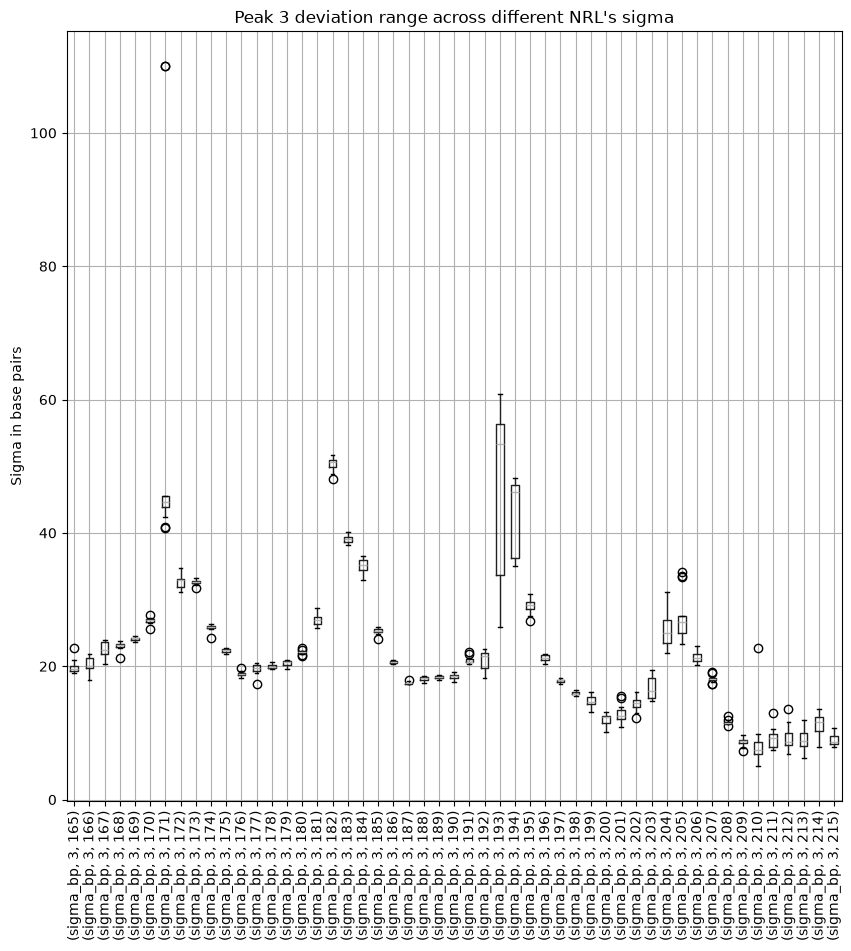

In [20]:
# make a new df with just the peak 3 and y_value data for sigma

sigma_peak3_df = pd.DataFrame(sigma_values_peak_3)

sigma_peak3_df['y_value'] = plot_x_discrete_value

# now maybe pivot it 

# this pivot is for peak 3, mu_bp values, and the different nrl lengths as y_values
sigma_peak3_nrls_for_boxplot = sigma_peak3_df.pivot( columns= 'y_value')

###################
# all peaks for sigma
sigma_peak1_df = pd.DataFrame(sigma_values_peak_1)
sigma_peak2_df = pd.DataFrame(sigma_values_peak_2)
sigma_peak3_df = pd.DataFrame(sigma_values_peak_3)
sigma_peak4_df = pd.DataFrame(sigma_values_peak_4)
sigma_peak5_df = pd.DataFrame(sigma_values_peak_5)
# add y_value
sigma_peak1_df['y_value'] = plot_x_discrete_value
sigma_peak2_df['y_value'] = plot_x_discrete_value
sigma_peak3_df['y_value'] = plot_x_discrete_value
sigma_peak4_df['y_value'] = plot_x_discrete_value
sigma_peak5_df['y_value'] = plot_x_discrete_value
# make the boxplot df
sigma_peak1_nrls_for_boxplot = sigma_peak1_df.pivot( columns= 'y_value')
sigma_peak2_nrls_for_boxplot = sigma_peak2_df.pivot( columns= 'y_value')
sigma_peak3_nrls_for_boxplot = sigma_peak3_df.pivot( columns= 'y_value')
sigma_peak4_nrls_for_boxplot = sigma_peak4_df.pivot( columns= 'y_value')
sigma_peak5_nrls_for_boxplot = sigma_peak5_df.pivot( columns= 'y_value')


# fig, ax = plt.subplots()
# ax.plot(mu_peak3_nrls_for_boxplot)
# fig.set_size_inches(7,7)
sigma_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
plt.xticks(rotation = 90 )
plt.title("Peak 3 deviation range across different NRL's sigma")
plt.ylabel("Sigma in base pairs")
plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_sigma_peak3.pdf")
plt.show()
plt.close()

# plt.

# plt.box(mu_peak3_nrls_for_boxplot )

                             mu_bp                                      ...  \
component                        3                                      ...   
y_value                        165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                             ...   
NRL165_12nucs_2kbt_trial_1   254.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10  239.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11  236.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12  239.6 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13  236.7 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                            ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7     NaN NaN NaN NaN NaN N

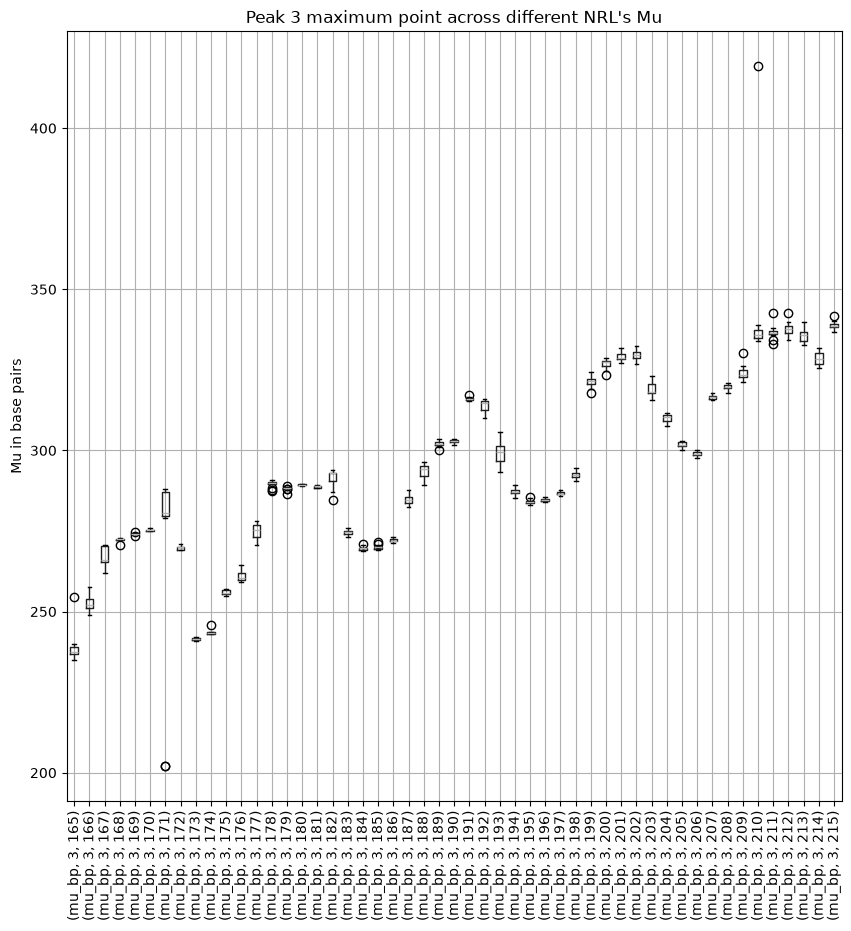

In [34]:

###################
# all peaks for sigma
mu_peak1_df = pd.DataFrame(mu_values_peak_1)
mu_peak2_df = pd.DataFrame(mu_values_peak_2)
mu_peak3_df = pd.DataFrame(mu_values_peak_3)
mu_peak4_df = pd.DataFrame(mu_values_peak_4)
mu_peak5_df = pd.DataFrame(mu_values_peak_5)
# add y_value
mu_peak1_df['y_value'] = plot_x_discrete_value
mu_peak2_df['y_value'] = plot_x_discrete_value
mu_peak3_df['y_value'] = plot_x_discrete_value
mu_peak4_df['y_value'] = plot_x_discrete_value
mu_peak5_df['y_value'] = plot_x_discrete_value
# make the boxplot df
mu_peak1_nrls_for_boxplot = mu_peak1_df.pivot( columns= 'y_value')
mu_peak2_nrls_for_boxplot = mu_peak2_df.pivot( columns= 'y_value')
mu_peak3_nrls_for_boxplot = mu_peak3_df.pivot( columns= 'y_value')
mu_peak4_nrls_for_boxplot = mu_peak4_df.pivot( columns= 'y_value')
mu_peak5_nrls_for_boxplot = mu_peak5_df.pivot( columns= 'y_value')



# make a new df with just the peak 3 and y_value data

new_peak3_df = pd.DataFrame(mu_values_peak_3)

new_peak3_df['y_value'] = plot_x_discrete_value

# now maybe pivot it 

# this pivot is for peak 3, mu_bp values, and the different nrl lengths as y_values
mu_peak3_nrls_for_boxplot = new_peak3_df.pivot( columns= 'y_value')

print(mu_peak3_nrls_for_boxplot)

# fig, ax = plt.subplots()
# ax.plot(mu_peak3_nrls_for_boxplot)
# fig.set_size_inches(7,7)
mu_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
plt.xticks(rotation = 90 )
plt.title("Peak 3 maximum point across different NRL's Mu")
plt.ylabel("Mu in base pairs")
plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_MU_peak3.pdf")
plt.show()
plt.close()

# plt.

# plt.box(mu_peak3_nrls_for_boxplot )

                            amplitude_A                                      \
component                             3                                       
y_value                             165 166 167 168 169 170 171 172 173 174   
sample_name                                                                   
NRL165_12nucs_2kbt_trial_1     117.5100 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_10    159.7870 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_11    207.5980 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_12    160.9686 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_13    207.2479 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                                 ...  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NRL215_12nucs_2kbt_trial_5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_6          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_7          NaN NaN NaN NaN 

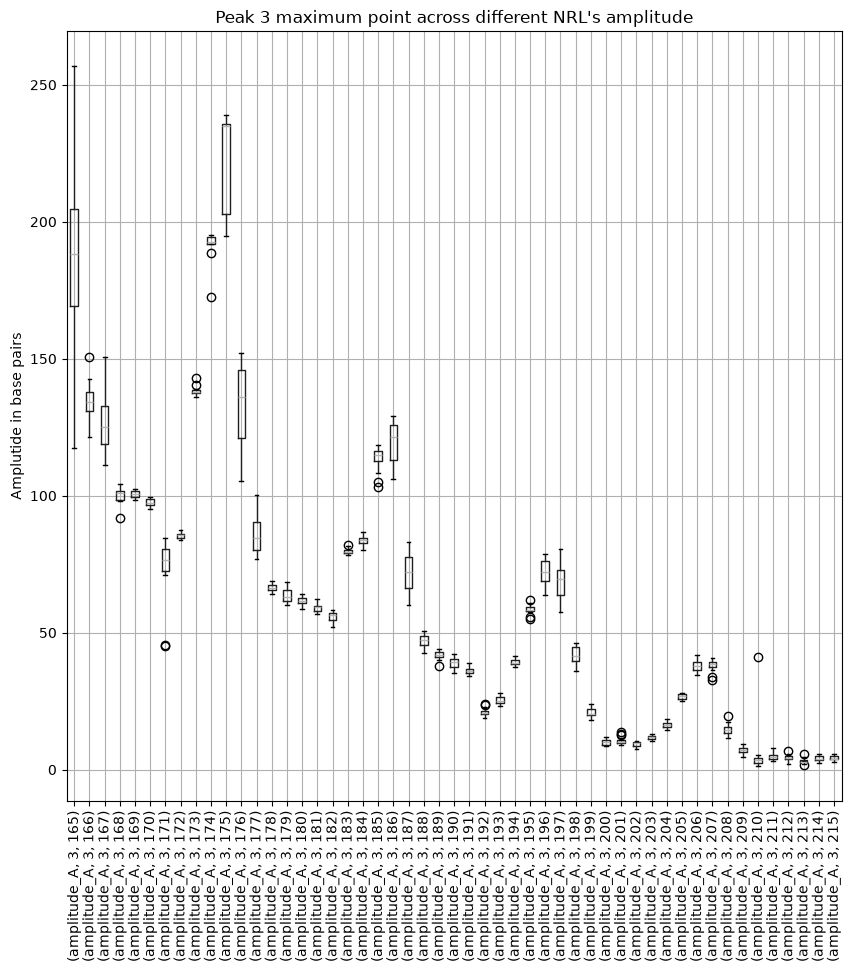

In [9]:

# this will be the amplitude for peak 3

amplitude_peak3_df = pd.DataFrame(amplitude_values_peak_3)

amplitude_peak3_df['y_value'] = plot_x_discrete_value

# now maybe pivot it 

# this pivot is for peak 3, mu_bp values, and the different nrl lengths as y_values
amplitude_peak3_nrls_for_boxplot = amplitude_peak3_df.pivot( columns= 'y_value')

print(amplitude_peak3_nrls_for_boxplot)

# fig, ax = plt.subplots()
# ax.plot(mu_peak3_nrls_for_boxplot)
# fig.set_size_inches(7,7)
amplitude_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
plt.xticks(rotation = 90 )
plt.title("Peak 3 maximum point across different NRL's amplitude")
plt.ylabel("Amplutide in base pairs")
plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_amplitude_peak3.pdf")
plt.show()
plt.close()

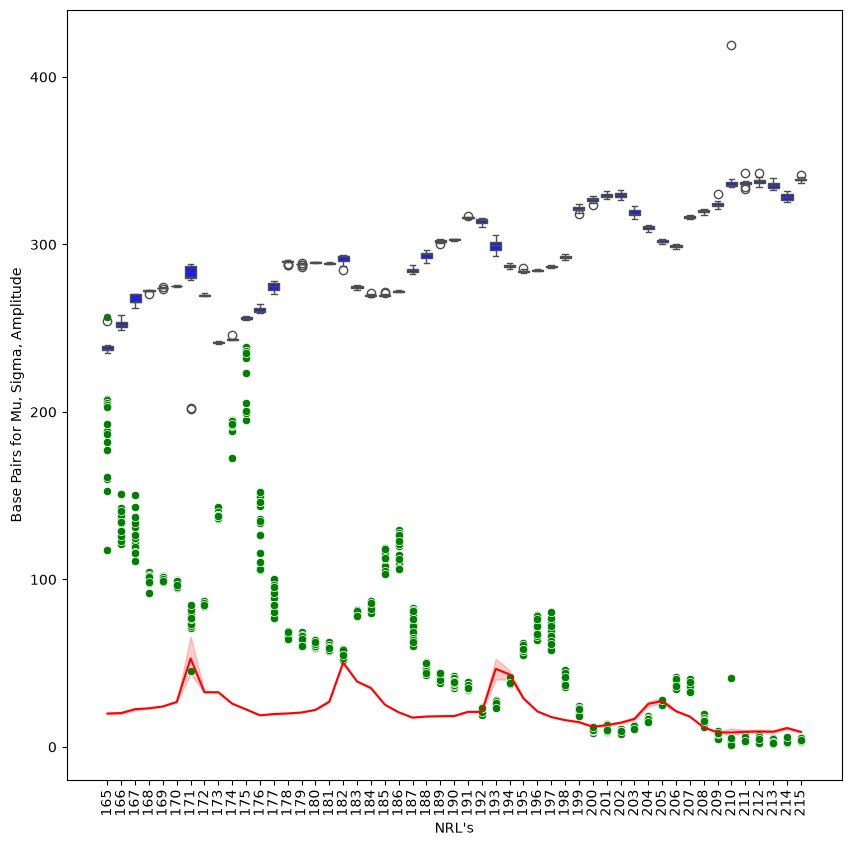

In [10]:
# now want to see if i can do a stacked boxplot or stacked plot of any kind

# for peak 3 mu and sigma

# mu_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
# plt.xticks(rotation = 90 )
# plt.title("Peak 3 maximum point across different NRL's Mu")
# plt.ylabel("Mu in base pairs")
# plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_MU_peak3.pdf")
# plt.show()
# plt.close()

# sigma_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
# plt.xticks(rotation = 90 )
# plt.title("Peak 3 deviation range across different NRL's sigma")
# plt.ylabel("Sigma in base pairs")
# plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_sigma_peak3.pdf")
# plt.show()
# plt.close()

# amplitude_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
# plt.xticks(rotation = 90 )
# plt.title("Peak 3 maximum point across different NRL's amplitude")
# plt.ylabel("Amplutide in base pairs")
# plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_amplitude_peak3.pdf")
# plt.show()
# plt.close()

# mu_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=(10,10), patch_artist = True)
# plt.colormaps['Blues']
# sigma_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
# amplitude_peak3_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"), )
# plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

# Melt the dataframe from wide to long format so Seaborn can read it
df_long_mu = mu_peak3_nrls_for_boxplot.melt()
df_long_sigma = sigma_peak3_nrls_for_boxplot.melt()
df_long_amplitude = amplitude_peak3_nrls_for_boxplot.melt()
# print(df_long)
# Plot using the 'Blues' palette natively

# can easily switch back to boxplot from lineplot or scatterplot
sns.boxplot(
    data=df_long_mu, 
    x='y_value', 
    y='value', 
    color='Blue',    # Ensures each box gets its own color from the palette
    legend=False, 
)
sns.lineplot(
    data=df_long_sigma, 
    x='y_value', 
    y='value', 
    color='Red',    # Ensures each box gets its own color from the palette
    legend=False, 
)
sns.scatterplot(
    data=df_long_amplitude, 
    x='y_value', 
    y='value', 
    color='Green',    # Ensures each box gets its own color from the palette
    legend=False, 
)
plt.xticks(fontsize=10, rotation = 90)
plt.xlabel("NRL's")
plt.ylabel("Base Pairs for Mu, Sigma, Amplitude")
plt.show()
plt.close()


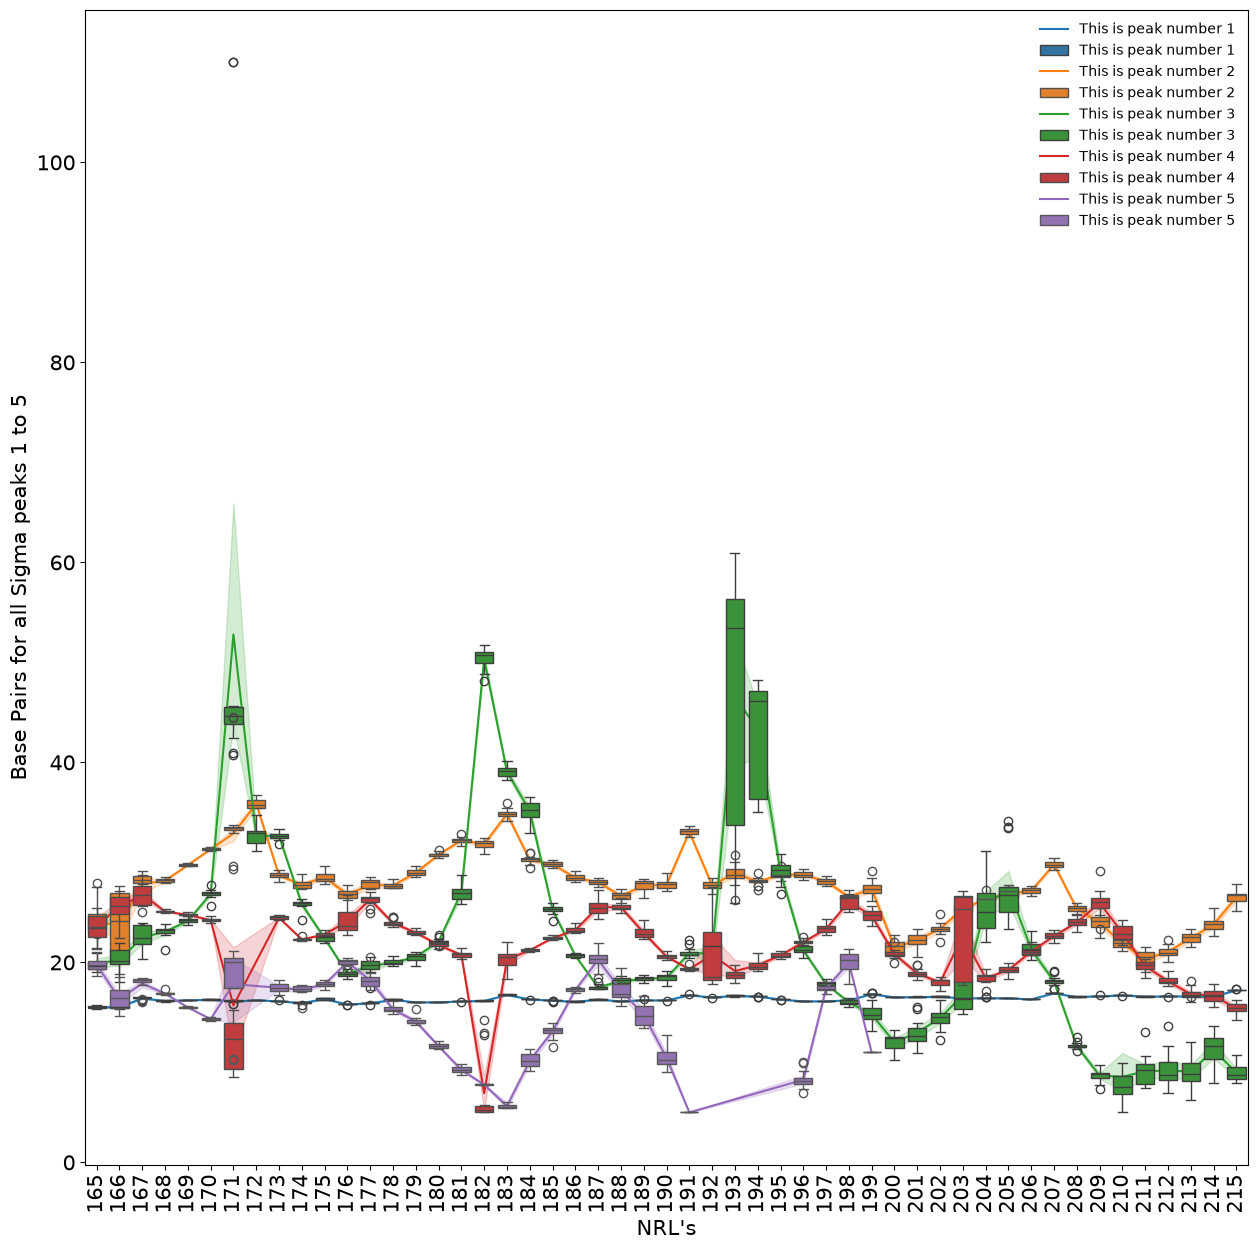

In [61]:

## plotting all peaks sigma in a stacked plot

df_long_sigma1 = sigma_peak1_nrls_for_boxplot.melt()
df_long_sigma2 = sigma_peak2_nrls_for_boxplot.melt()
df_long_sigma3 = sigma_peak3_nrls_for_boxplot.melt()
df_long_sigma4 = sigma_peak4_nrls_for_boxplot.melt()
df_long_sigma5 = sigma_peak5_nrls_for_boxplot.melt()

# sns.lineplot(
#     data=df_long_sigma, 
#     x='y_value', 
#     y='value', 
#     color='',    # Ensures each box gets its own color from the palette
#     legend=False, 
# )
# sns.lineplot(
#     data=df_long_sigma1, 
#     x='y_value', 
#     y='value', 
#     color='Blue',    # Ensures each box gets its own color from the palette
#     legend=False, 
# )
# sns.lineplot(
#     data=df_long_sigma2, 
#     x='y_value', 
#     y='value', 
#     color='Red',    # Ensures each box gets its own color from the palette
#     legend=False, 
# )
# sns.lineplot(
#     data=df_long_sigma3, 
#     x='y_value', 
#     y='value', 
#     color='Green',    # Ensures each box gets its own color from the palette
#     legend=False, 
# )
# sns.lineplot(
#     data=df_long_sigma4, 
#     x='y_value', 
#     y='value', 
#     color='Orange',    # Ensures each box gets its own color from the palette
#     legend=False, 
# )
# sns.lineplot(
#     data=df_long_sigma5, 
#     x='y_value', 
#     y='value', 
#     color='Black',    # Ensures each box gets its own color from the palette
#     legend=False, 
# )

df_list = [df_long_sigma1,df_long_sigma2,df_long_sigma3,df_long_sigma4,df_long_sigma5,]

peak_num = 1
plt.figure(figsize=(15, 15))
for x in df_list:
    sns.lineplot(
        
        data=x, 
        label="This is peak number "+ str(peak_num),
        x='y_value', 
        y='value',    # Ensures each box gets its own color from the palette,    
    )
    sns.boxplot(
        
        data=x, 
        label="This is peak number "+ str(peak_num),
        x='y_value', 
        y='value',    # Ensures each box gets its own color from the palette,    
    )
    plt.xticks(fontsize=15, rotation = 90)
    plt.yticks(fontsize=15)
    plt.xlabel("NRL's", fontsize=15)
    plt.ylabel("Base Pairs for all Sigma peaks 1 to 5", fontsize=15)
    plt.legend(frameon=False, fontsize=10)
    peak_num+=1
plt.savefig("./all_loop_nrl_165_to_215_results/stacked_boxlineplot_showing_all_5_peaks_sigma_together.pdf")
plt.show()
    # plt.close()


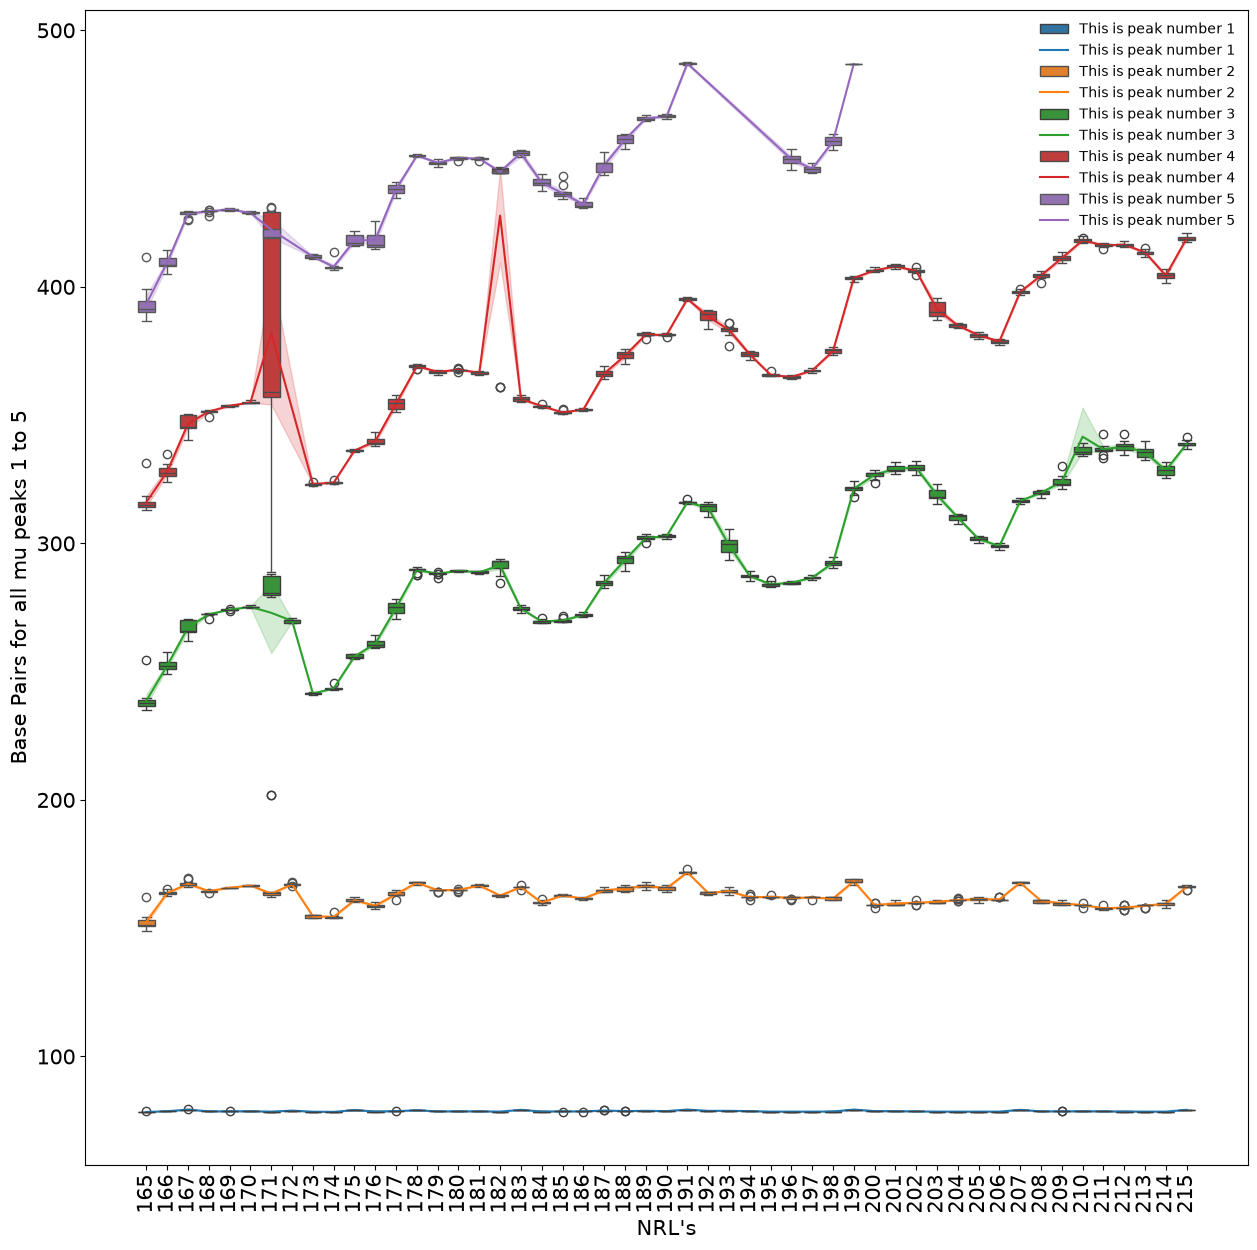

In [60]:
## plotting all peaks mu in a stacked plot

df_long_mu1 = mu_peak1_nrls_for_boxplot.melt()
df_long_mu2 = mu_peak2_nrls_for_boxplot.melt()
df_long_mu3 = mu_peak3_nrls_for_boxplot.melt()
df_long_mu4 = mu_peak4_nrls_for_boxplot.melt()
df_long_mu5 = mu_peak5_nrls_for_boxplot.melt()


df_list_mu = [df_long_mu1,df_long_mu2,df_long_mu3,df_long_mu4,df_long_mu5,]

peak_num = 1
plt.figure(figsize=(15, 15))
for x in df_list_mu:
    sns.boxplot(
        
        data=x, 
        label="This is peak number "+ str(peak_num),
        x='y_value', 
        y='value',    # Ensures each box gets its own color from the palette,    
    )
    sns.lineplot(
        
        data=x, 
        label="This is peak number "+ str(peak_num),
        x='y_value', 
        y='value',    # Ensures each box gets its own color from the palette,    
    )
    plt.xticks(fontsize=15, rotation = 90)
    plt.yticks(fontsize=15)
    plt.xlabel("NRL's", fontsize =15)
    plt.ylabel("Base Pairs for all mu peaks 1 to 5", fontsize = 15)
    plt.legend(frameon=False, fontsize = 10)
    peak_num+=1
plt.savefig("./all_loop_nrl_165_to_215_results/stacked_boxlineplot_showing_all_5_peaks_mu_together.pdf")
plt.show()

In [45]:
# ?pd.DataFrame.boxplot
# ?plt.colormaps
# list(plt.colormaps)

?sns.boxplot

Signature:
sns.boxplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    dodge='auto',
    width=0.8,
    gap=0,
    whis=1.5,
    linecolor='auto',
    linewidth=None,
    fliersize=None,
    hue_norm=None,
    native_scale=False,
    log_scale=None,
    formatter=None,
    legend='auto',
    ax=None,
    **kwargs,
)
Docstring:
Draw a box plot to show distributions with respect to categories.

A box plot (or box-and-whisker plot) shows the distribution of quantitative
data in a way that facilitates comparisons between variables or across
levels of a categorical variable. The box shows the quartiles of the
dataset while the whiskers extend to show the rest of the distribution,
except for points that are determined to be "outliers" using a method
that is a function of the inter-quartile range.

See the :ref:`tutorial <categorical_tutorial>` for more i

In [11]:

# testing the fliers
# mu_peak3_dict = mu_peak3_nrls_for_boxplot.boxplot(return_type = "dict")

# mu_peak3_dict["fliers"][3].get_ydata()

####################################################################################################
# I should just make a for loop that loops through every NRL and calcualtes the quartiles and inter quartile range for each column(NRL)

# then remove the outliers that are above and below from the data.
# but i need to record which values are outliers, then unpivot the dataframe so I can map it back to the original dataframe
# this will ensure i dont just remove the mu but all the other values. 

# actually, I just need to find the sample that produced that outlier and remove it altogether.

# this is the general formula to find the outliers
# make a for loop to move through the NRL's
Q1 = mu_peak3_nrls_for_boxplot[[("mu_bp",3,str(165))]].quantile(0.25)
Q3 = mu_peak3_nrls_for_boxplot[[("mu_bp",3,str(165))]].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

################
# see if i can get the sample names that make the outliers

outliers_greater = mu_peak3_nrls_for_boxplot[mu_peak3_nrls_for_boxplot[[("mu_bp",3,str(165))]] > upper_bound]

# print(outliers_greater)

# this gives the sample name for the trial that was problematic
outliers_greater = mu_peak3_nrls_for_boxplot[[("mu_bp",3,str(165))]] > upper_bound

# print(outliers_greater.iloc[:,0] )
print(outliers_greater.index[outliers_greater.iloc[:,0] == True][0])


##################
# geting the outliers less than also 
outliers_less = mu_peak3_nrls_for_boxplot[mu_peak3_nrls_for_boxplot[[("mu_bp",3,str(165))]] < lower_bound]

# print(outliers_less)
outliers_less = mu_peak3_nrls_for_boxplot[[("mu_bp",3,str(165))]] < lower_bound
print(outliers_less)

# print(outliers_less.index)
# outliers_less.loc['NRL165_12nucs_2kbt_trial_1'][('mu_bp',3,str(165))] == False

# this should solve for the case that there are no values that are true, so it will not raise an error.
lower_outlier_names = []
for sample in outliers_less.index:
    if outliers_less.loc[sample][('mu_bp',3,str(165))] == True:
        # print(sample)
        lower_outlier_names.append(sample)

    
# print(outliers_less.index[outliers_less.iloc[:,0] == True][0])

NRL165_12nucs_2kbt_trial_1
                             mu_bp
component                        3
y_value                        165
sample_name                       
NRL165_12nucs_2kbt_trial_1   False
NRL165_12nucs_2kbt_trial_10  False
NRL165_12nucs_2kbt_trial_11  False
NRL165_12nucs_2kbt_trial_12  False
NRL165_12nucs_2kbt_trial_13  False
...                            ...
NRL215_12nucs_2kbt_trial_5   False
NRL215_12nucs_2kbt_trial_6   False
NRL215_12nucs_2kbt_trial_7   False
NRL215_12nucs_2kbt_trial_8   False
NRL215_12nucs_2kbt_trial_9   False

[765 rows x 1 columns]


In [17]:
lower_outlier_names

[]

[1 2 3 4 5]
                            mu_bp                                      ...  \
component                       1                                      ...   
y_value                       165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                            ...   
NRL165_12nucs_2kbt_trial_1   78.7 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10  78.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11  78.3 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12  78.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13  78.3 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                           ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5    NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6    NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7    NaN NaN NaN NaN NaN Na

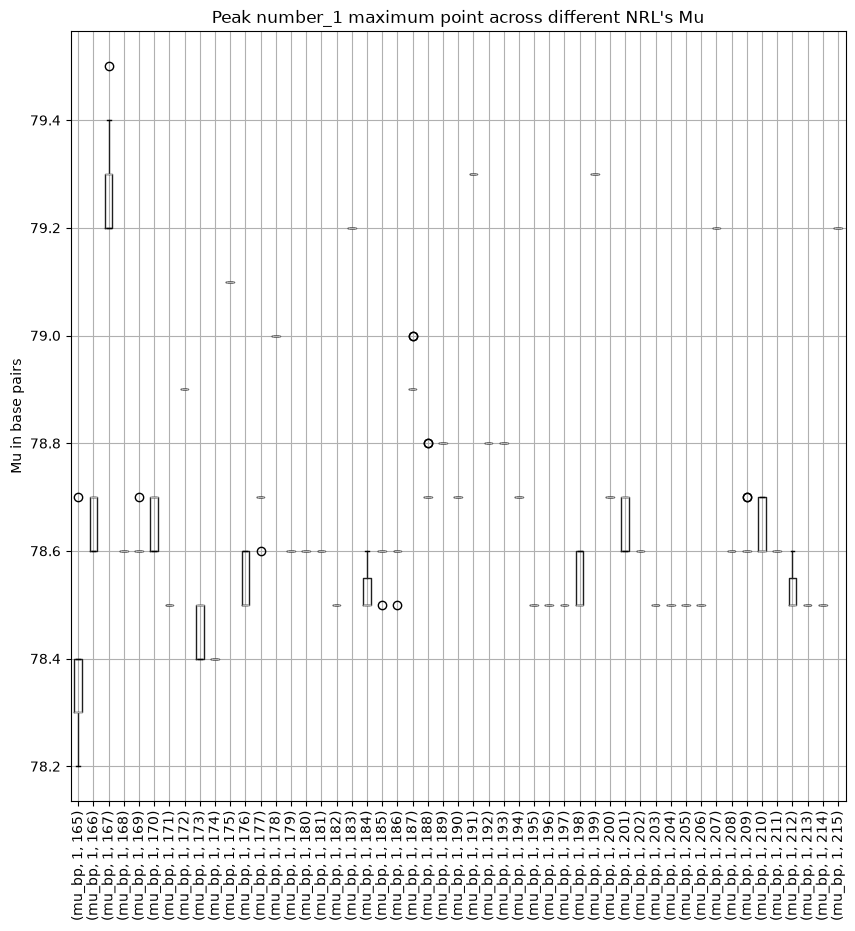

                            sigma_bp                                      ...  \
component                          1                                      ...   
y_value                          165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                               ...   
NRL165_12nucs_2kbt_trial_1      15.6 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10     15.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11     15.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12     15.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13     15.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                              ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7  

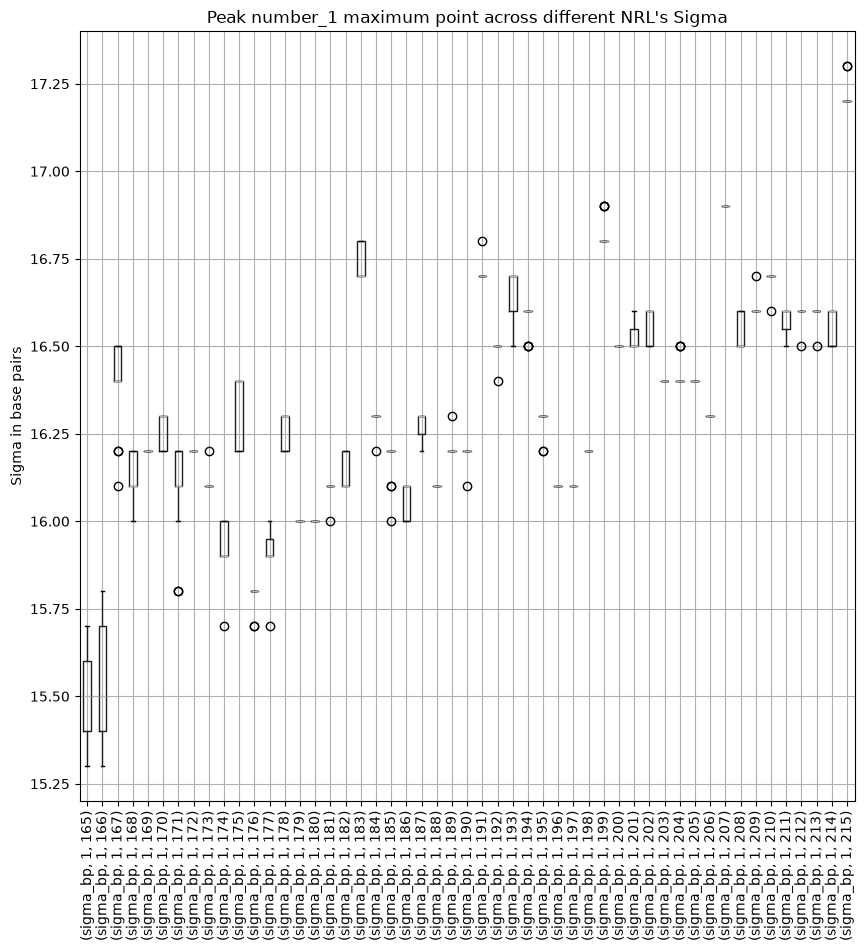

                            amplitude_A                                      \
component                             1                                       
y_value                             165 166 167 168 169 170 171 172 173 174   
sample_name                                                                   
NRL165_12nucs_2kbt_trial_1     883.6970 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_10    885.1974 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_11    890.3282 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_12    887.8773 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_13    889.8993 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                                 ...  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NRL215_12nucs_2kbt_trial_5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_6          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_7          NaN NaN NaN NaN 

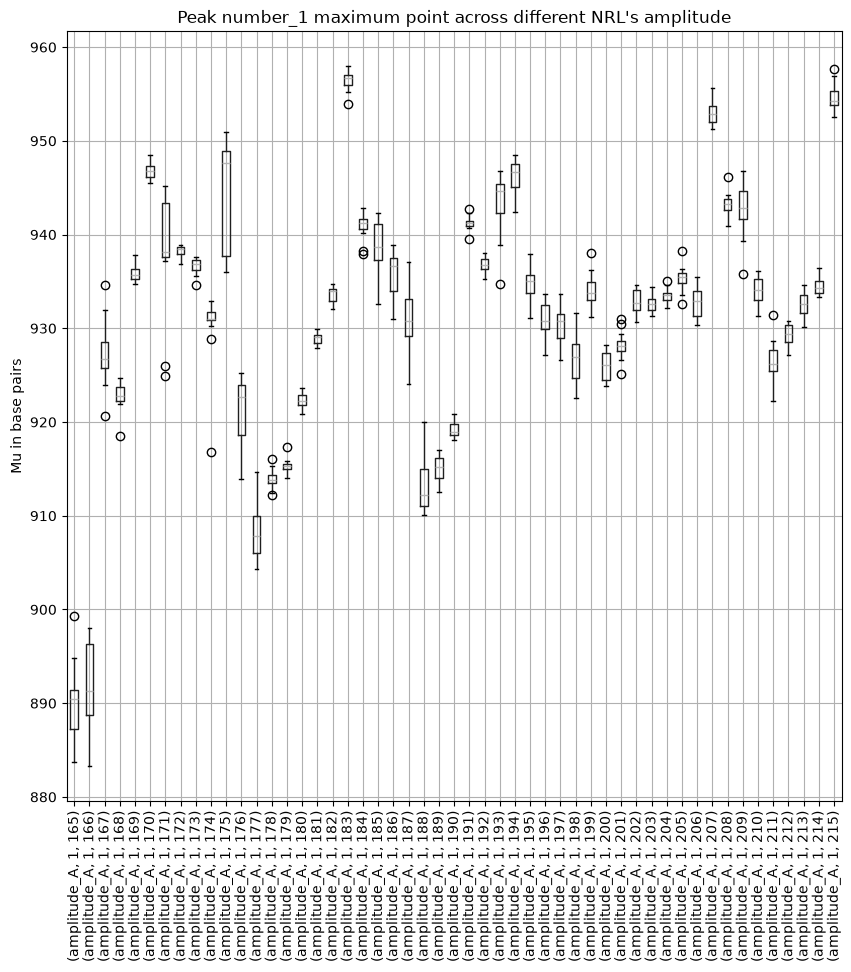

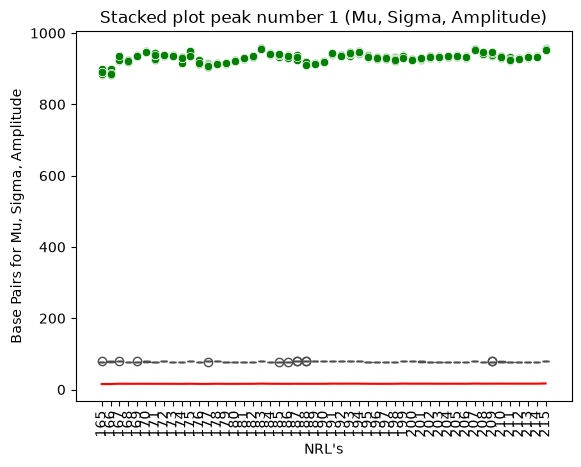

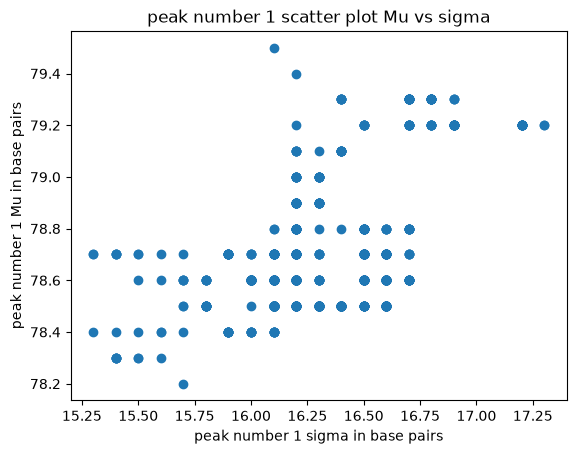

                             mu_bp                                      ...  \
component                        2                                      ...   
y_value                        165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                             ...   
NRL165_12nucs_2kbt_trial_1   162.2 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10  153.7 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11  150.3 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12  154.3 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13  151.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                            ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7     NaN NaN NaN NaN NaN N

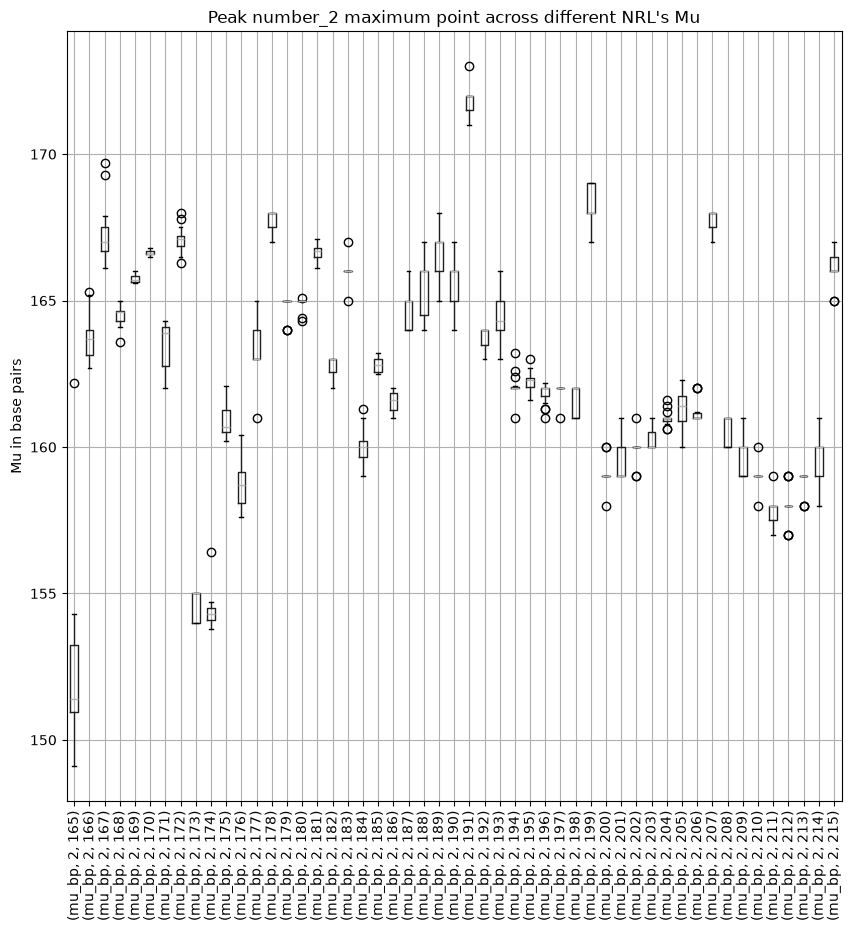

                            sigma_bp                                      ...  \
component                          2                                      ...   
y_value                          165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                               ...   
NRL165_12nucs_2kbt_trial_1      27.9 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10     24.9 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11     22.7 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12     25.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13     23.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                              ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7  

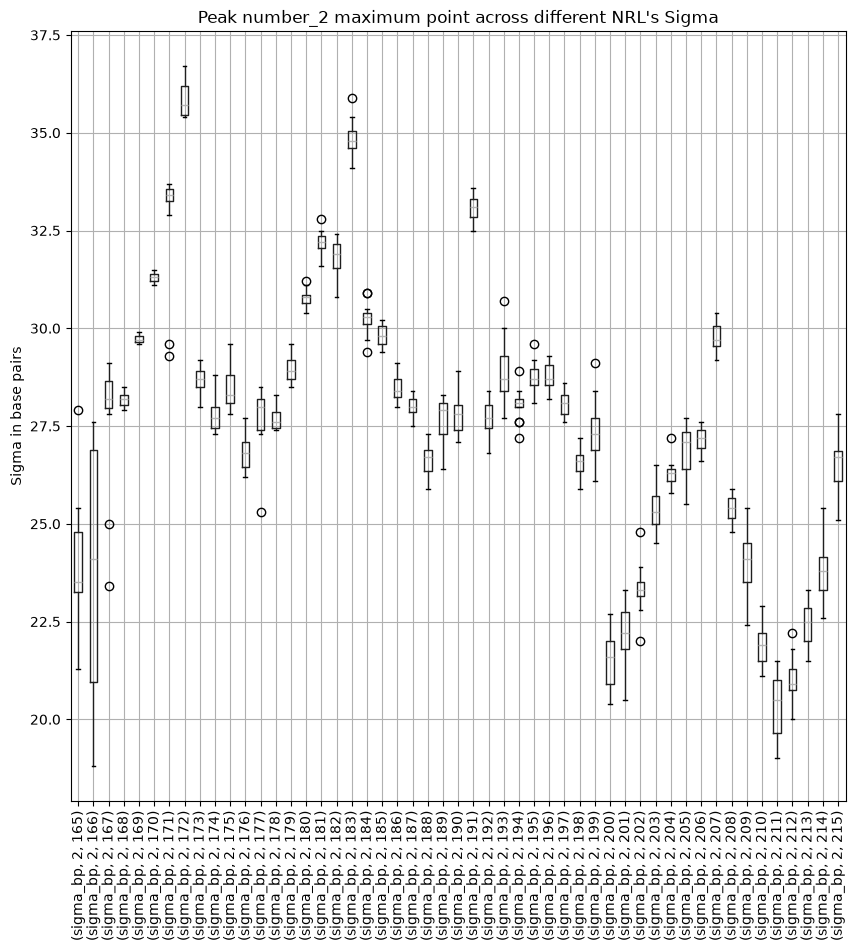

                            amplitude_A                                      \
component                             2                                       
y_value                             165 166 167 168 169 170 171 172 173 174   
sample_name                                                                   
NRL165_12nucs_2kbt_trial_1      74.0099 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_10     82.3856 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_11     97.3861 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_12     86.6938 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_13     96.0862 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                                 ...  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NRL215_12nucs_2kbt_trial_5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_6          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_7          NaN NaN NaN NaN 

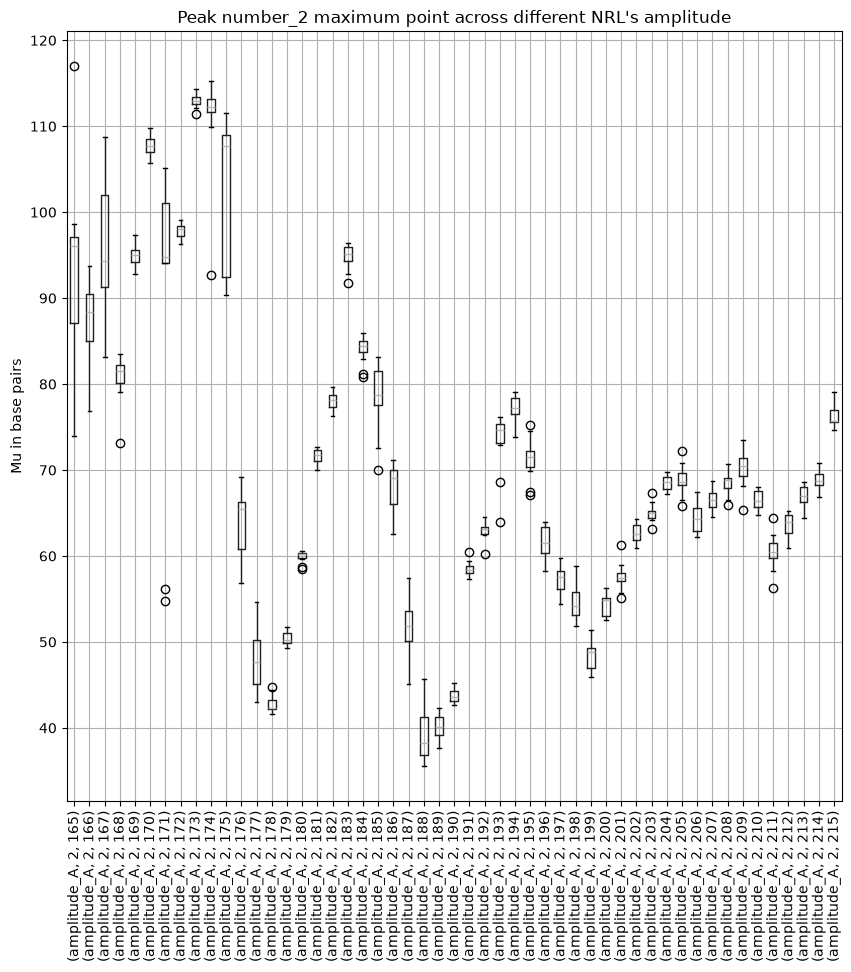

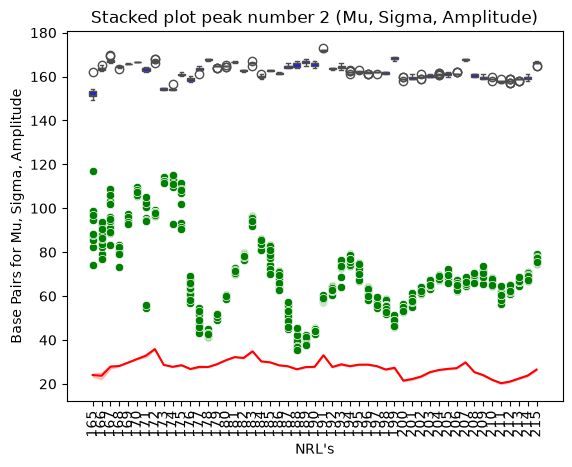

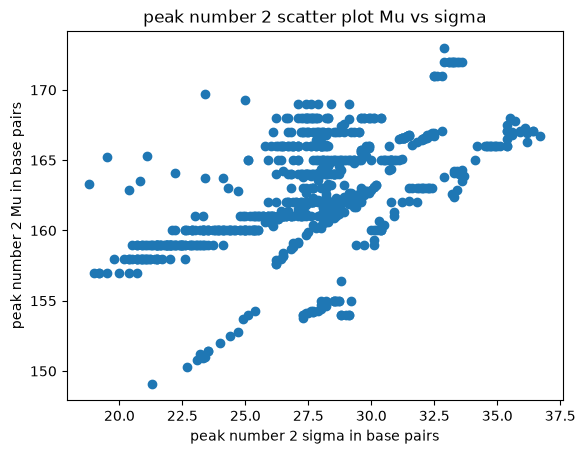

                             mu_bp                                      ...  \
component                        3                                      ...   
y_value                        165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                             ...   
NRL165_12nucs_2kbt_trial_1   254.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10  239.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11  236.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12  239.6 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13  236.7 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                            ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7     NaN NaN NaN NaN NaN N

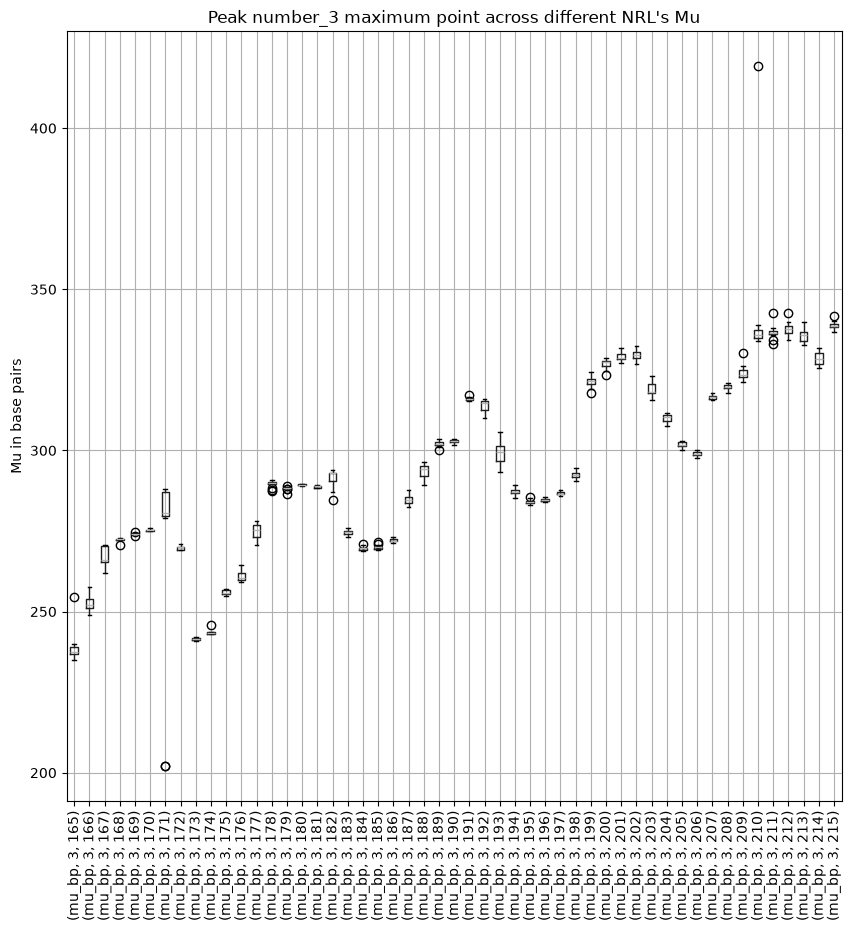

                            sigma_bp                                      ...  \
component                          3                                      ...   
y_value                          165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                               ...   
NRL165_12nucs_2kbt_trial_1      22.8 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10     19.6 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11     19.3 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12     20.2 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13     19.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                              ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7  

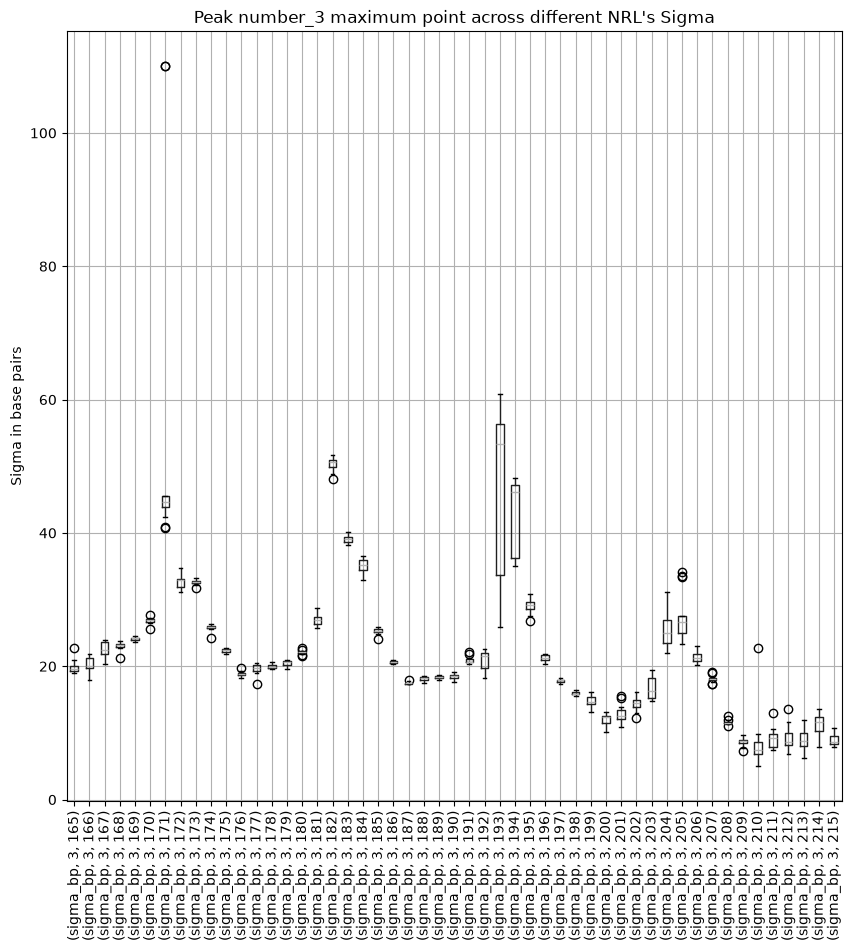

                            amplitude_A                                      \
component                             3                                       
y_value                             165 166 167 168 169 170 171 172 173 174   
sample_name                                                                   
NRL165_12nucs_2kbt_trial_1     117.5100 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_10    159.7870 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_11    207.5980 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_12    160.9686 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_13    207.2479 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                                 ...  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NRL215_12nucs_2kbt_trial_5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_6          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_7          NaN NaN NaN NaN 

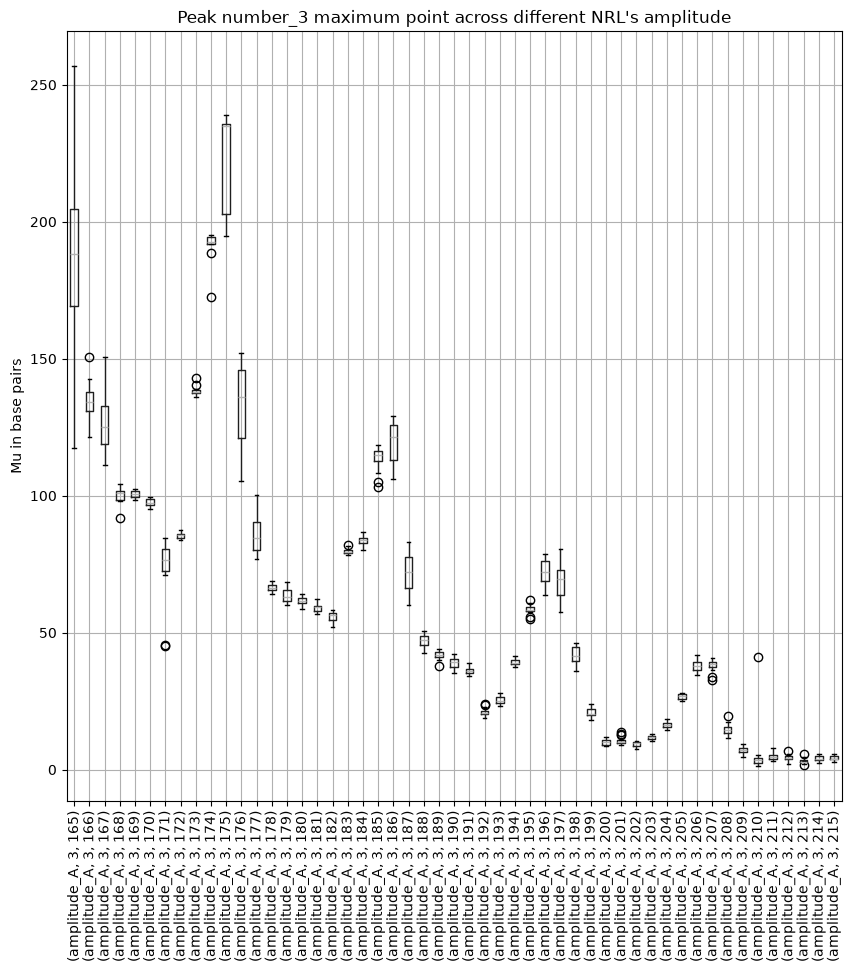

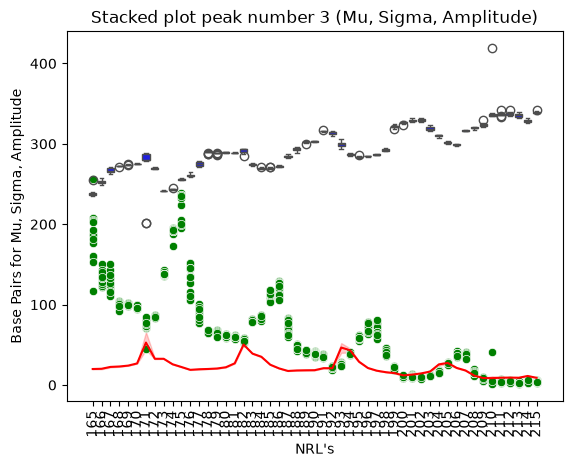

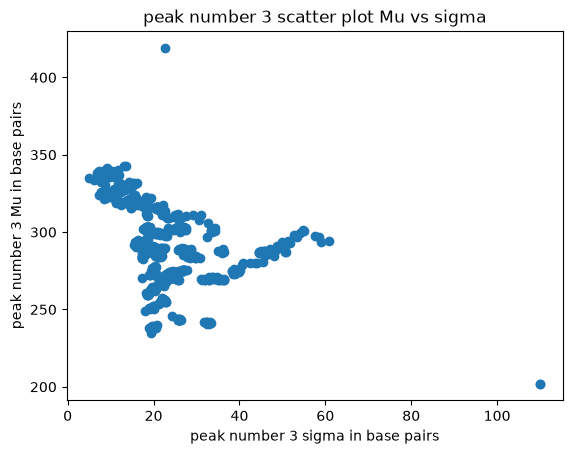

                             mu_bp                                      ...  \
component                        4                                      ...   
y_value                        165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                             ...   
NRL165_12nucs_2kbt_trial_1   331.3 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10  316.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11  313.8 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12  316.2 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13  313.6 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                            ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7     NaN NaN NaN NaN NaN N

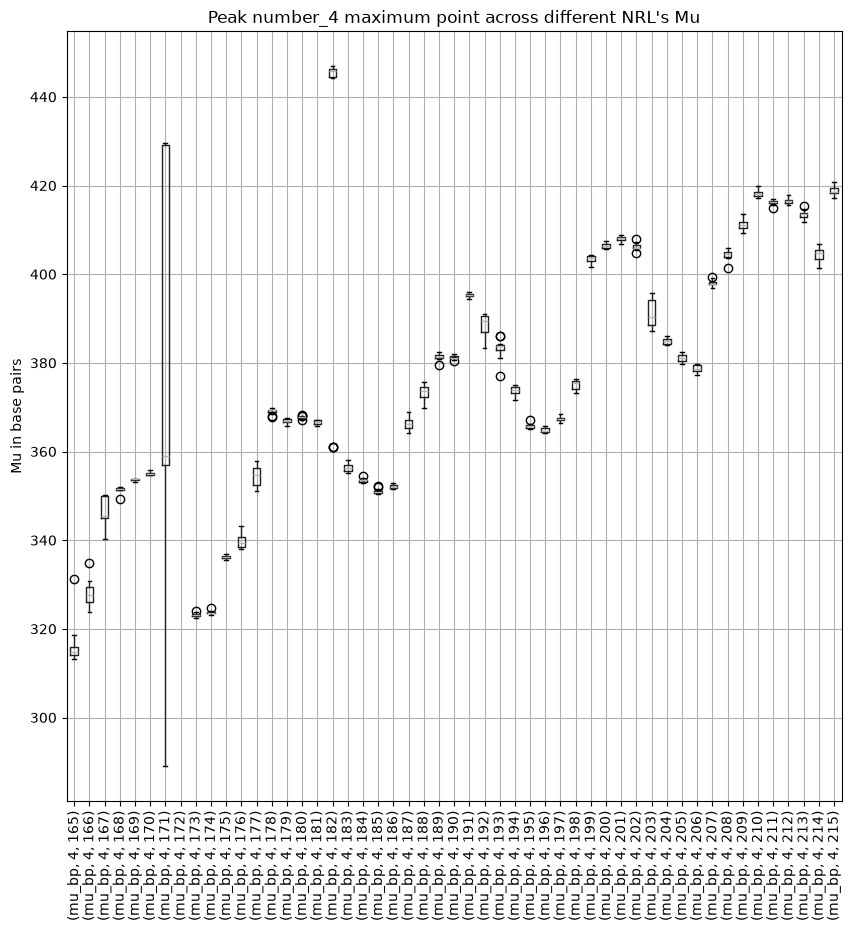

                            sigma_bp                                      ...  \
component                          4                                      ...   
y_value                          165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                               ...   
NRL165_12nucs_2kbt_trial_1      26.2 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10     24.7 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11     22.1 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12     25.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13     22.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                              ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7  

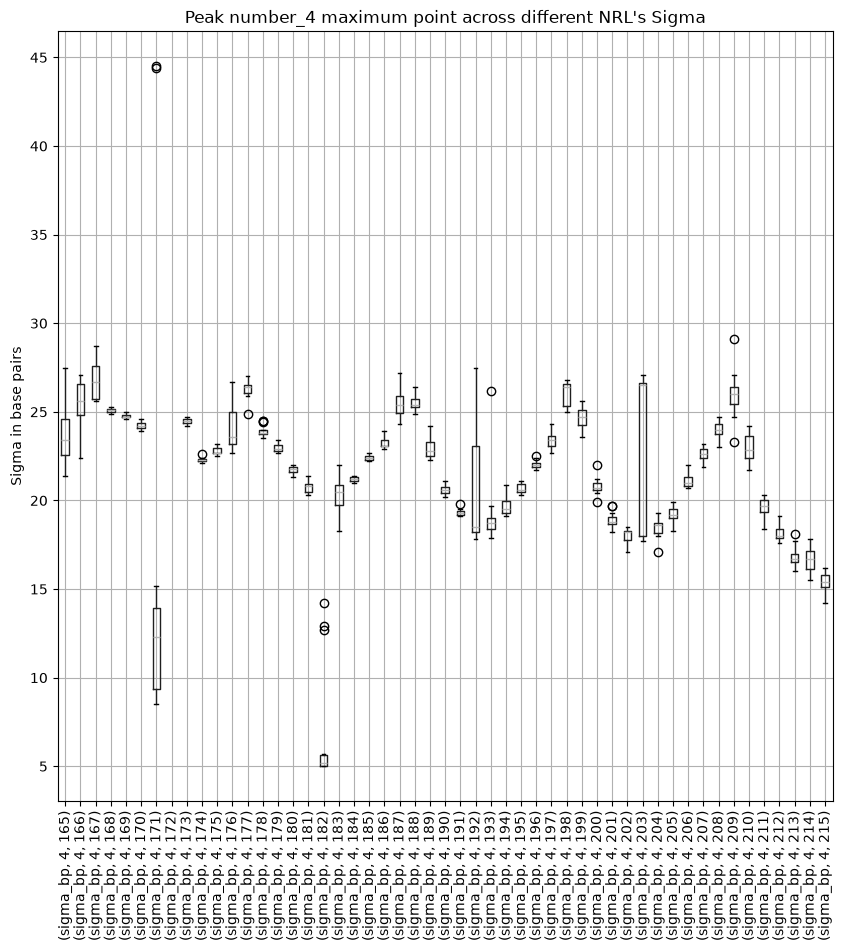

                            amplitude_A                                      \
component                             4                                       
y_value                             165 166 167 168 169 170 171 172 173 174   
sample_name                                                                   
NRL165_12nucs_2kbt_trial_1     160.3863 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_10    164.7431 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_11    200.0864 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_12    168.6338 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_13    201.4779 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                                 ...  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NRL215_12nucs_2kbt_trial_5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_6          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_7          NaN NaN NaN NaN 

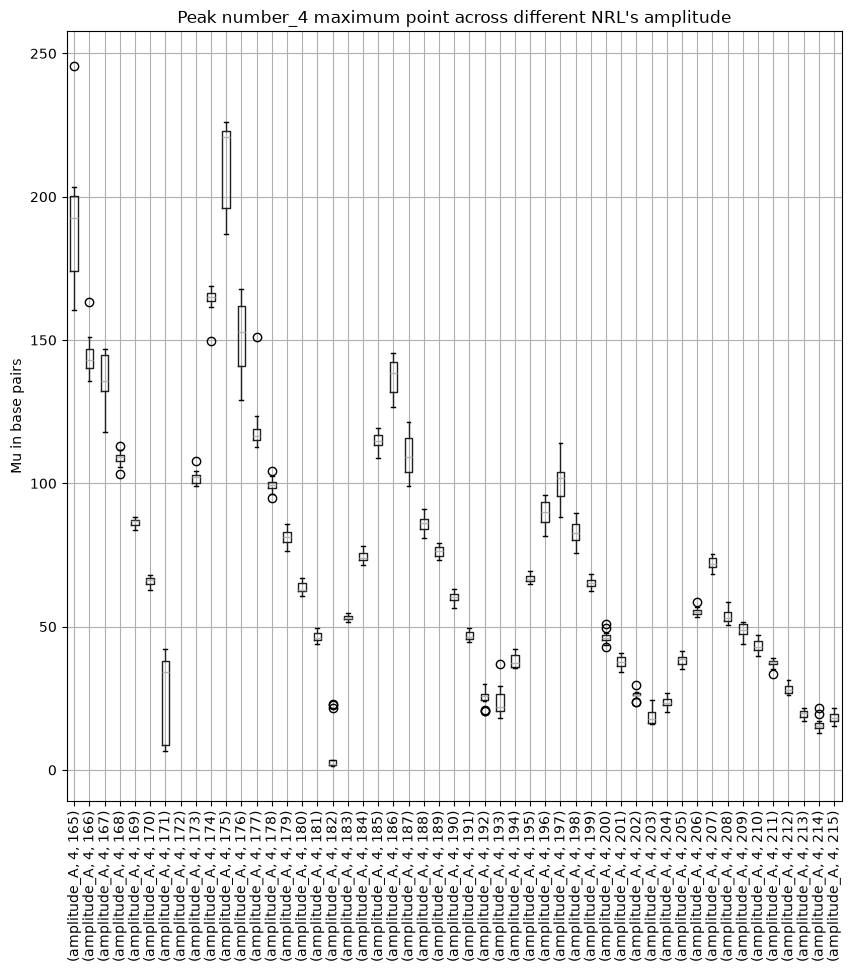

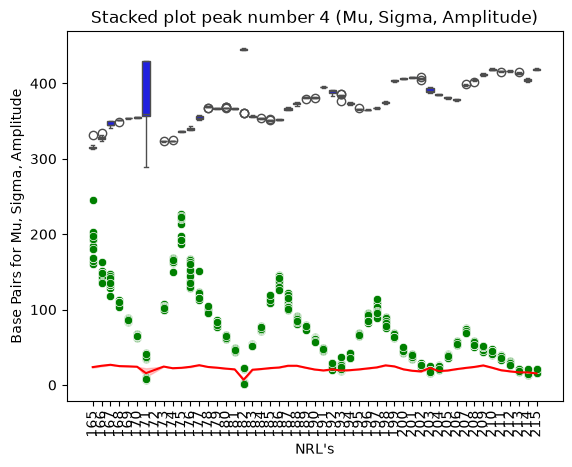

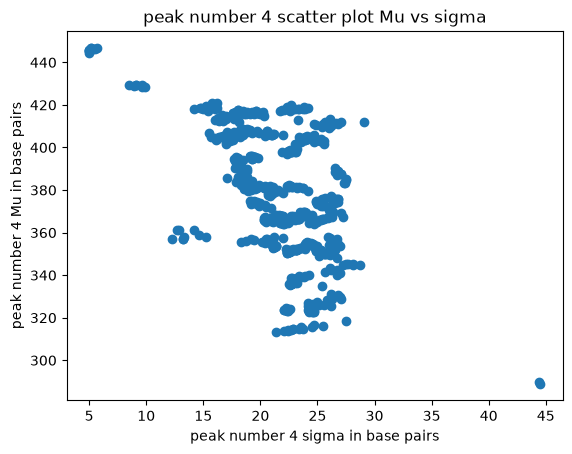

                             mu_bp                                      ...  \
component                        5                                      ...   
y_value                        165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                             ...   
NRL165_12nucs_2kbt_trial_1   411.6 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10  395.1 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11  389.7 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12  395.4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13  389.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                            ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7     NaN NaN NaN NaN NaN N

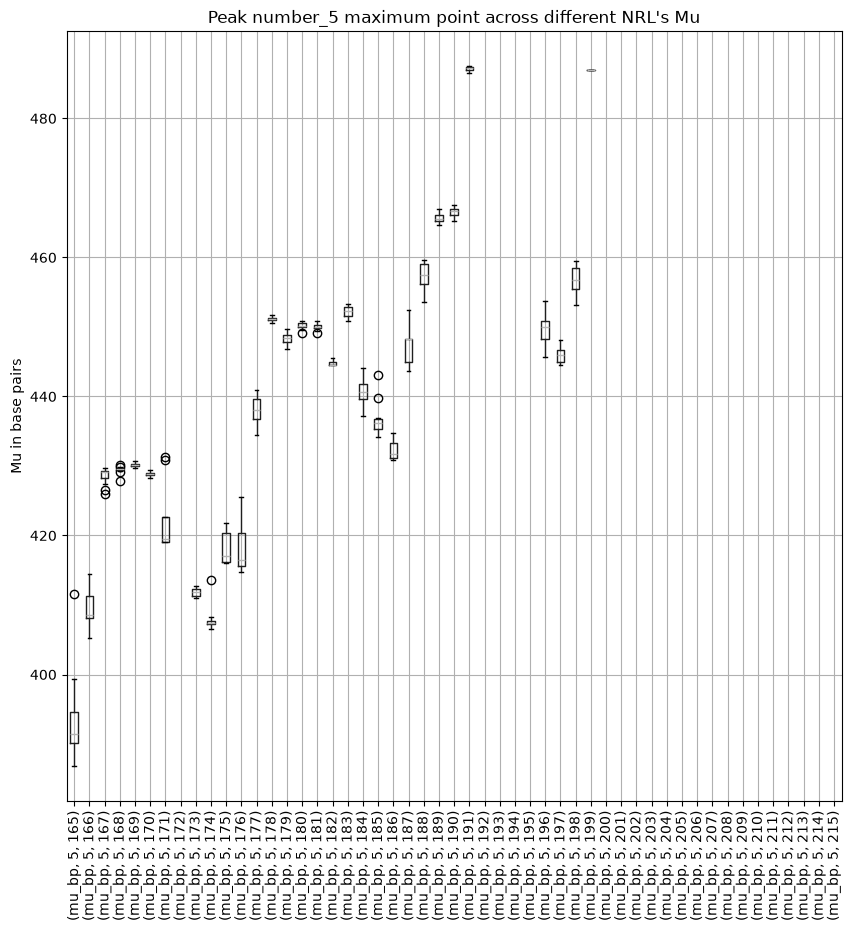

                            sigma_bp                                      ...  \
component                          5                                      ...   
y_value                          165 166 167 168 169 170 171 172 173 174  ...   
sample_name                                                               ...   
NRL165_12nucs_2kbt_trial_1      18.6 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_10     19.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_11     19.2 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_12     19.7 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL165_12nucs_2kbt_trial_13     19.6 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                              ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
NRL215_12nucs_2kbt_trial_5       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_6       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
NRL215_12nucs_2kbt_trial_7  

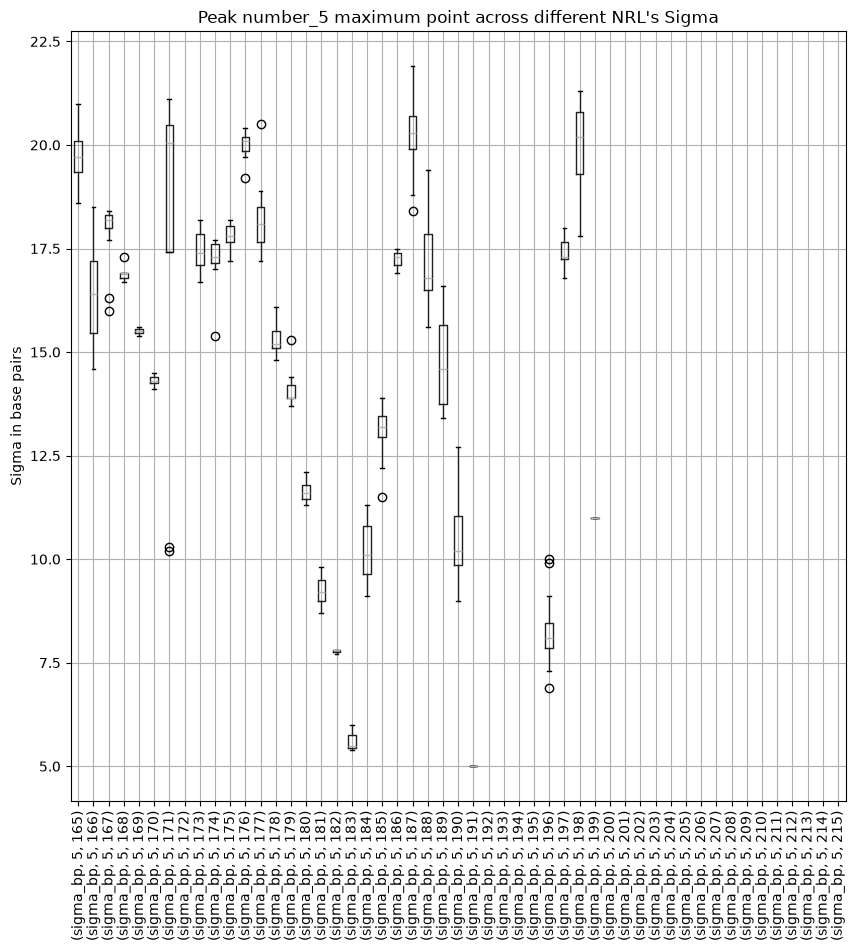

                            amplitude_A                                      \
component                             5                                       
y_value                             165 166 167 168 169 170 171 172 173 174   
sample_name                                                                   
NRL165_12nucs_2kbt_trial_1     104.8284 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_10     65.4008 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_11     66.1140 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_12     66.5749 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL165_12nucs_2kbt_trial_13     66.4384 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                                 ...  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NRL215_12nucs_2kbt_trial_5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_6          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
NRL215_12nucs_2kbt_trial_7          NaN NaN NaN NaN 

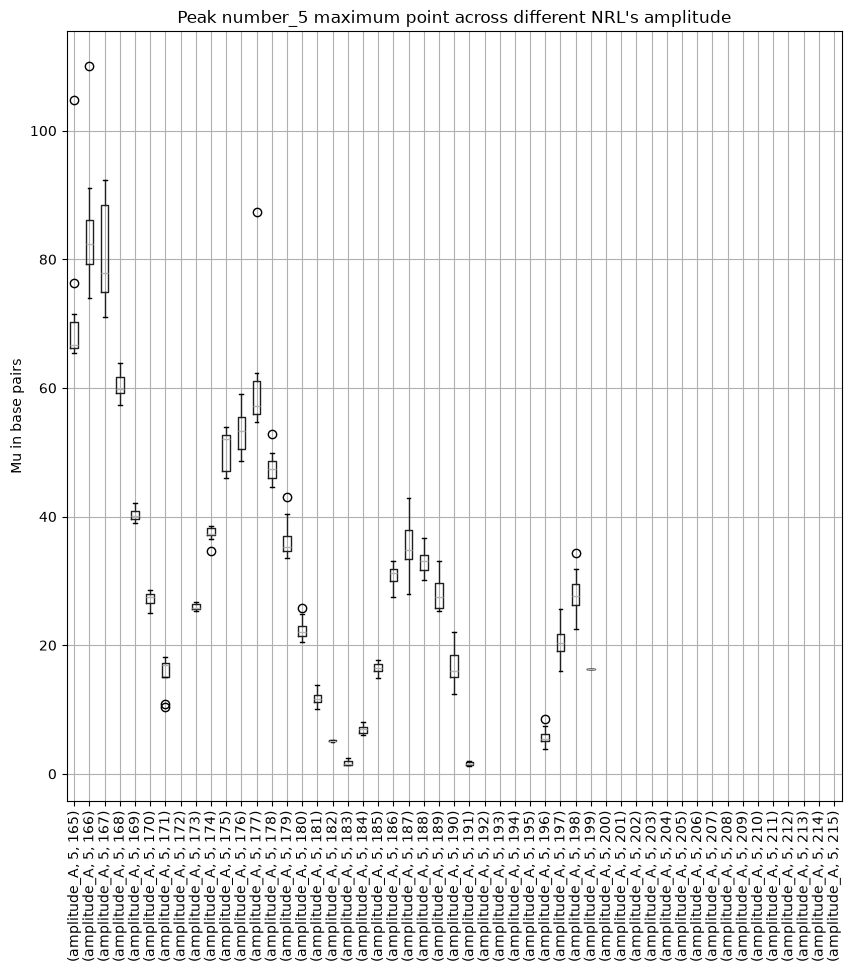

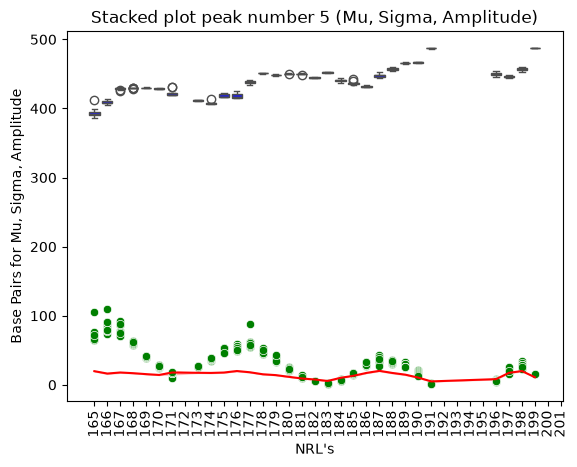

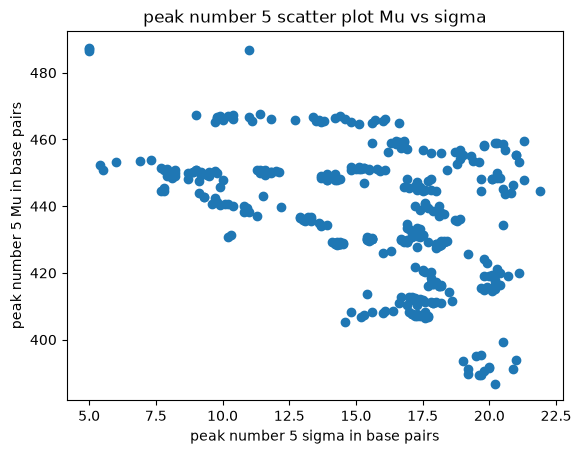

In [16]:
# outliers_greater = mu_peak3_nrls_for_boxplot[[("mu_bp",3,str(165))]] > upper_bound

# outliers_greater.index[outliers_greater.iloc[:,0] == True][0]
# outliers_greater

# mu_peak3_nrls_for_boxplot


## here i can make a nested for loop, the first loop goes through the peak number, the second for loop goes through the nrl
## this will give me all the sample names that are outliers in the mu data. 
## I will make 2 other nested for loops for the sigma and amplitude.
## once I have all the sample names that contributed to some outlier, i will remove those names from the main data table


# need to loop throught each peak here, then make it a dataframe and add the 'y_value' column onto it
# then I will have 'the_dataframe' where I loop through each nrl for that peak number

number_of_peaks = np.arange(1,5+1)
print(number_of_peaks)
all_nrls = np.arange(165, 215+1)

# for loop for mu values
greater_outlier_names_mu = []
lower_outlier_names_mu = []
for Peaknum in number_of_peaks:
    
    mu_values_peak_Peaknum = df_wide[[('mu_bp', Peaknum)]]
    plot_x_discrete_value = df_wide['y_value']
    
    first_dataframe = pd.DataFrame(mu_values_peak_Peaknum)
    
    first_dataframe['y_value'] = plot_x_discrete_value
    # print(first_dataframe)

    # this pivot is for peak #, mu_bp values, and the different nrl lengths as y_values
    the_dataframe = first_dataframe.pivot( columns= 'y_value')
    print(the_dataframe)

    file_output_name = "boxplot_full_simulation_data_mu_peaknum_"+str(Peaknum)+".pdf"

    # I think i can plot all the boxplots here
    the_dataframe.boxplot(fontsize= 10, figsize=("10","10"))
    plt.xticks(rotation = 90 )
    plt.title("Peak number_"+ str(Peaknum)+  " maximum point across different NRL's Mu")
    plt.ylabel("Mu in base pairs")
    plt.savefig(fname="./all_loop_nrl_165_to_215_results/"+str(file_output_name))
    plt.show()
    plt.close()

    # here will be sigma plotted

    sigma_values_peak_Peaknum = df_wide[[('sigma_bp', Peaknum)]]
    plot_x_discrete_value = df_wide['y_value']
    
    sigma_dataframe = pd.DataFrame(sigma_values_peak_Peaknum)
    
    sigma_dataframe['y_value'] = plot_x_discrete_value
    # print(first_dataframe)

    # this pivot is for peak #, mu_bp values, and the different nrl lengths as y_values
    the_sig_dataframe = sigma_dataframe.pivot( columns= 'y_value')
    print(the_sig_dataframe)

    file_output_name_sigma = "boxplot_full_simulation_data_sigma_peaknum_"+str(Peaknum)+".pdf"

    # I think i can plot all the boxplots here
    the_sig_dataframe.boxplot(fontsize= 10, figsize=("10","10"))
    plt.xticks(rotation = 90 )
    plt.title("Peak number_"+ str(Peaknum)+  " maximum point across different NRL's Sigma")
    plt.ylabel("Sigma in base pairs")
    plt.savefig(fname="./all_loop_nrl_165_to_215_results/"+str(file_output_name_sigma))
    plt.show()
    plt.close()

    # here will plot the amplitude

    amplitude_values_peak_Peaknum = df_wide[[('amplitude_A', Peaknum)]]
    plot_x_discrete_value = df_wide['y_value']
    
    amplitude_dataframe = pd.DataFrame(amplitude_values_peak_Peaknum)
    
    amplitude_dataframe['y_value'] = plot_x_discrete_value
    # print(first_dataframe)

    # this pivot is for peak #, mu_bp values, and the different nrl lengths as y_values
    the_amplitude_dataframe = amplitude_dataframe.pivot( columns= 'y_value')
    print(the_amplitude_dataframe)

    file_output_name_amplitude = "boxplot_full_simulation_data_amplitude_peaknum_"+str(Peaknum)+".pdf"

    # I think i can plot all the boxplots here
    the_amplitude_dataframe.boxplot(fontsize= 10, figsize=("10","10"))
    plt.xticks(rotation = 90 )
    plt.title("Peak number_"+ str(Peaknum)+  " maximum point across different NRL's amplitude")
    plt.ylabel("Mu in base pairs")
    plt.savefig(fname="./all_loop_nrl_165_to_215_results/"+str(file_output_name_amplitude))
    plt.show()
    plt.close()


    # now to make a stacked plot for all three per peak

    file_output_name_stacked_plot = "Stacked_peak_"+str(Peaknum)+"_showing_Mu_Sigma_Amplitude.pdf"
    # Melt the dataframe from wide to long format so Seaborn can read it
    df_long_mu = the_dataframe.melt()
    df_long_sigma = the_sig_dataframe.melt()
    df_long_amplitude = the_amplitude_dataframe.melt()
    # print(df_long)
    # Plot using the 'Blues' palette natively
    
    # can easily switch back to boxplot from lineplot or scatterplot
    sns.boxplot(
        data=df_long_mu, 
        x='y_value', 
        y='value', 
        color='Blue',    # Ensures each box gets its own color from the palette
        legend=False, 
    )
    sns.lineplot(
        data=df_long_sigma, 
        x='y_value', 
        y='value', 
        color='Red',    # Ensures each box gets its own color from the palette
        legend=False, 
    )
    sns.scatterplot(
        data=df_long_amplitude, 
        x='y_value', 
        y='value', 
        color='Green',    # Ensures each box gets its own color from the palette
        legend=False, 
    )
    plt.xticks(fontsize=10, rotation = 90)
    plt.title("Stacked plot peak number " +str(Peaknum)+" (Mu, Sigma, Amplitude)")
    plt.xlabel("NRL's")
    plt.ylabel("Base Pairs for Mu, Sigma, Amplitude")
    plt.savefig("./all_loop_nrl_165_to_215_results/"+str(file_output_name_stacked_plot))
    plt.show()
    plt.close()

    # now to do the scatter plot, because only sigma and mu are in base pairs, the amplitude is in frequency so not comparable

    file_output_name_scattered_plot = "Scatter_plot_for_peak_number_" +str(Peaknum)+ "_Mu_vs_sigma.pdf"
    plt.scatter(  the_sig_dataframe, the_dataframe)
    plt.xlabel("peak number " +str(Peaknum)+ " sigma in base pairs")
    plt.ylabel("peak number " +str(Peaknum)+ " Mu in base pairs")
    plt.title("peak number " +str(Peaknum)+ " scatter plot Mu vs sigma")
    plt.savefig("./all_loop_nrl_165_to_215_results/"+str(file_output_name_scattered_plot))
    # plt.annotate()
    plt.show()
    plt.close()

    # we have nrl's from 165 to 215
    # all_nrls = np.arange(165, 215+1)
    # now I need to do another for loop to go through each nrl

    ### now i also have to loop through mu_bp, sigma_bp, amplitude_A, to get the outliers for each.
    for NRL_num in all_nrls:
        
        # we want to get the quartile information
        Q1 = the_dataframe[[("mu_bp", Peaknum, str(NRL_num))]].quantile(0.25)
        Q3 = the_dataframe[[("mu_bp", Peaknum, str(NRL_num))]].quantile(0.75)

        # now to calculate inter quartile rage, so we can find data points that lay outside
        IQR = Q3-Q1

        lower_bound = Q1 - 1.5 * IQR

        upper_bound = Q3 + 1.5 * IQR

        # this just gives back boolean 
        outliers_greater = the_dataframe[the_dataframe[[("mu_bp",Peaknum,str(NRL_num))]] > upper_bound]

        # this gets the name that was greater than upper bound, so the outlier
        outliers_greater = the_dataframe[[("mu_bp",Peaknum,str(NRL_num))]] > upper_bound
        # print(outliers_greater)

        # now to fix the problem if this list is empty
        # greater_outlier_names_mu = []
        # there might be some duplicates because in different peaks, the same nrl trial might contribute to outliers 
        for sample in outliers_greater.index:
            if outliers_greater.loc[sample][('mu_bp',Peaknum,str(NRL_num))] == True:
                # print(sample)
                greater_outlier_names_mu.append(sample)

        # now for the lesser outliers
        # this just gives back boolean 
        outliers_lower = the_dataframe[the_dataframe[[("mu_bp",Peaknum,str(NRL_num))]] < lower_bound]

        # # this gets the name that was greater than upper bound, so the outlier
        outliers_lower = the_dataframe[[("mu_bp",Peaknum,str(NRL_num))]] < lower_bound

        # # now to fix the problem if this list is empty
        # # lower_outlier_names_mu = []
        for sample in outliers_lower.index:
            if outliers_lower.loc[sample][('mu_bp',Peaknum,str(NRL_num))] == True:
                # print(sample)
                lower_outlier_names_mu.append(sample)
        


In [9]:
#greater_outlier_names_mu
# lower_outlier_names_mu 

all_outlier_names_mu = list()

print(len(greater_outlier_names_mu))
print(len(lower_outlier_names_mu))
# pd.DataFrame(greater_outlier_names_mu).drop_duplicates()
# now here I should filter the data and remove the outliers to see how much data I am left with

all_outlier_names_mu.extend(greater_outlier_names_mu)
# print(all_outlier_names_mu)
print(len(all_outlier_names_mu))

all_outlier_names_mu.extend(lower_outlier_names_mu)
print(len(all_outlier_names_mu))

print(df_wide)

# greater_outlier_dropped_df = df_wide.drop(greater_outlier_names_mu)
# print(greater_outlier_dropped_df)
# all_outliers_dropped_mu_df = greater_outlier_dropped_df.drop(lower_outlier_names_mu)
# print(all_outliers_dropped_mu_df)

# actual drop outliers
df_wide.drop(all_outlier_names_mu)

76
66
76
142
                            mu_bp                             sigma_bp        \
component                       1      2      3      4      5        1     2   
sample_name                                                                    
NRL165_12nucs_2kbt_trial_1   78.7  162.2  254.5  331.3  411.6     15.6  27.9   
NRL165_12nucs_2kbt_trial_10  78.4  153.7  239.5  316.4  395.1     15.4  24.9   
NRL165_12nucs_2kbt_trial_11  78.3  150.3  236.4  313.8  389.7     15.4  22.7   
NRL165_12nucs_2kbt_trial_12  78.4  154.3  239.6  316.2  395.4     15.5  25.4   
NRL165_12nucs_2kbt_trial_13  78.3  151.0  236.7  313.6  389.5     15.4  23.4   
...                           ...    ...    ...    ...    ...      ...   ...   
NRL215_12nucs_2kbt_trial_5   79.2  166.0  338.3  418.6    NaN     17.2  26.8   
NRL215_12nucs_2kbt_trial_6   79.2  166.0  340.3  420.3    NaN     17.2  26.7   
NRL215_12nucs_2kbt_trial_7   79.2  167.0  338.5  418.2    NaN     17.2  27.5   
NRL215_12nucs_2kbt_trial_8 

mu_bp                             sigma_bp        \
component                       1      2      3      4      5        1     2   
sample_name                                                                    
NRL165_12nucs_2kbt_trial_10  78.4  153.7  239.5  316.4  395.1     15.4  24.9   
NRL165_12nucs_2kbt_trial_11  78.3  150.3  236.4  313.8  389.7     15.4  22.7   
NRL165_12nucs_2kbt_trial_12  78.4  154.3  239.6  316.2  395.4     15.5  25.4   
NRL165_12nucs_2kbt_trial_13  78.3  151.0  236.7  313.6  389.5     15.4  23.4   
NRL165_12nucs_2kbt_trial_14  78.4  152.5  238.7  315.7  393.6     15.3  24.4   
...                           ...    ...    ...    ...    ...      ...   ...   
NRL215_12nucs_2kbt_trial_5   79.2  166.0  338.3  418.6    NaN     17.2  26.8   
NRL215_12nucs_2kbt_trial_6   79.2  166.0  340.3  420.3    NaN     17.2  26.7   
NRL215_12nucs_2kbt_trial_7   79.2  167.0  338.5  418.2    NaN     17.2  27.5   
NRL215_12nucs_2kbt_trial_8   79.2  166.0  339.7  418.3    NaN     17.3  26.2   
NRL215_12nucs_2kbt_trial_9   79.2  167.0  339.1  420.9    NaN     17.2  26.8   

                                               ... fit_area_recovery          \
component                       3     4     5  ...                 2       3   
sample_name                                    ...                             
NRL165_12nucs_2kbt_trial_10  19.6  24.7  19.5  ...            1.0007  1.0007   
NRL165_12nucs_2kbt_trial_11  19.3  22.1  19.2  ...            1.0006  1.0006   
NRL165_12nucs_2kbt_trial_12  20.2  25.5  19.7  ...            1.0007  1.0007   
NRL165_12nucs_2kbt_trial_13  19.4  22.4  19.6  ...            1.0006  1.0006   
NRL165_12nucs_2kbt_trial_14  19.3  23.6  19.0  ...            1.0007  1.0007   
...                           ...   ...   ...  ...               ...     ...   
NRL215_12nucs_2kbt_trial_5   10.0  16.2   NaN  ...            1.0009  1.0009   
NRL215_12nucs_2kbt_trial_6    8.7  15.8   NaN  ...            1.0009  1.0009   
NRL215_12nucs_2kbt_trial_7   10.4  16.0   NaN  ...            1.0009  1.0009   
NRL215_12nucs_2kbt_trial_8    8.5  14.2   NaN  ...            1.0009  1.0009   
NRL215_12nucs_2kbt_trial_9    8.3  15.8   NaN  ...            1.0009  1.0009   

                                            fit_baseline                    \
component                         4       5            1        2        3   
sample_name                                                                  
NRL165_12nucs_2kbt_trial_10  1.0007  1.0007      95.2113  95.2113  95.2113   
NRL165_12nucs_2kbt_trial_11  1.0006  1.0006      92.0446  92.0446  92.0446   
NRL165_12nucs_2kbt_trial_12  1.0007  1.0007      90.9365  90.9365  90.9365   
NRL165_12nucs_2kbt_trial_13  1.0006  1.0006      93.0532  93.0532  93.0532   
NRL165_12nucs_2kbt_trial_14  1.0007  1.0007      96.7159  96.7159  96.7159   
...                             ...     ...          ...      ...      ...   
NRL215_12nucs_2kbt_trial_5   1.0009     NaN      58.3080  58.3080  58.3080   
NRL215_12nucs_2kbt_trial_6   1.0009     NaN      58.6088  58.6088  58.6088   
NRL215_12nucs_2kbt_trial_7   1.0009     NaN      58.2090  58.2090  58.2090   
NRL215_12nucs_2kbt_trial_8   1.0009     NaN      57.5327  57.5327  57.5327   
NRL215_12nucs_2kbt_trial_9   1.0009     NaN      59.4991  59.4991  59.4991   

                                              y_value  
component                          4        5          
sample_name                                            
NRL165_12nucs_2kbt_trial_10  95.2113  95.2113     165  
NRL165_12nucs_2kbt_trial_11  92.0446  92.0446     165  
NRL165_12nucs_2kbt_trial_12  90.9365  90.9365     165  
NRL165_12nucs_2kbt_trial_13  93.0532  93.0532     165  
NRL165_12nucs_2kbt_trial_14  96.7159  96.7159     165  
...                              ...      ...     ...  
NRL215_12nucs_2kbt_trial_5   58.3080      NaN     215  
NRL215_12nucs_2kbt_trial_6   58.6088      NaN     215  
NRL215_12nucs_2kbt_trial_7   58.2090      NaN     215  
NRL215_12nucs_2kbt_tr

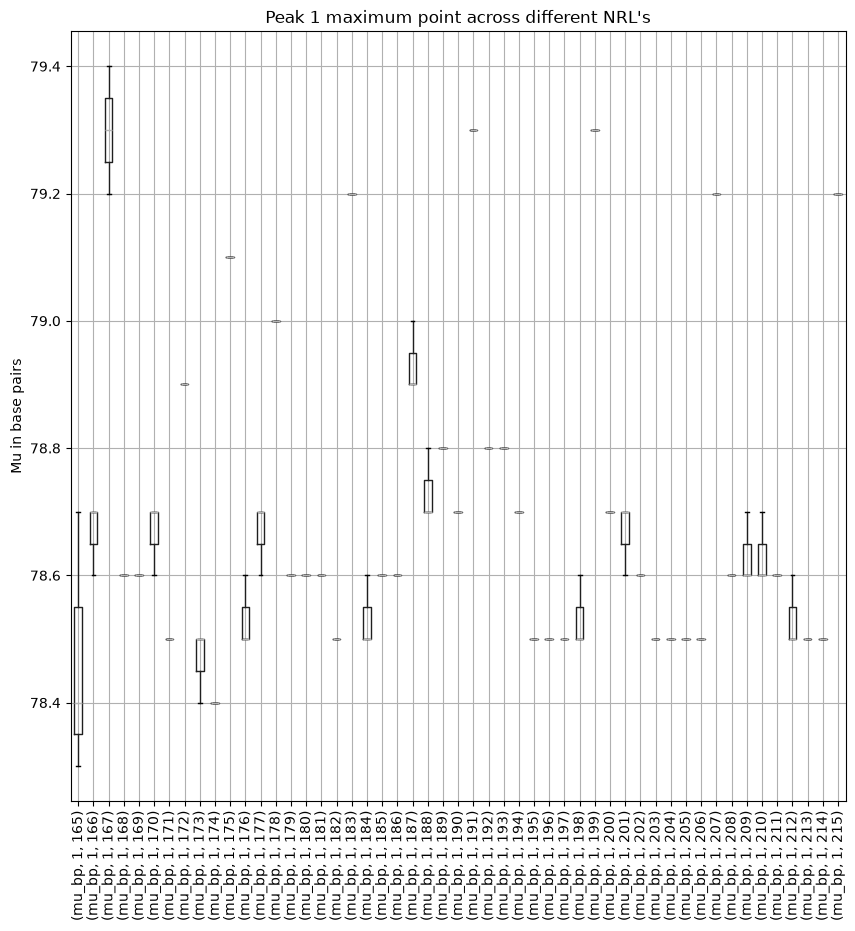

In [72]:
# make a new df with just the peak 3 and y_value data

new_peak1_df = pd.DataFrame(mu_values_peak_1)

new_peak1_df['y_value'] = plot_x_discrete_value

# now maybe pivot it 

# this pivot is for peak 3, mu_bp values, and the different nrl lengths as y_values
mu_peak1_nrls_for_boxplot = new_peak1_df.pivot( columns= 'y_value')

# fig, ax = plt.subplots()
# ax.plot(mu_peak3_nrls_for_boxplot)
# fig.set_size_inches(7,7)
mu_peak1_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
plt.xticks(rotation = 90 )
plt.title("Peak 1 maximum point across different NRL's")
plt.ylabel("Mu in base pairs")
plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_MU_peak1.pdf")
plt.show()
plt.close()

# plt.

# plt.box(mu_peak3_nrls_for_boxplot )

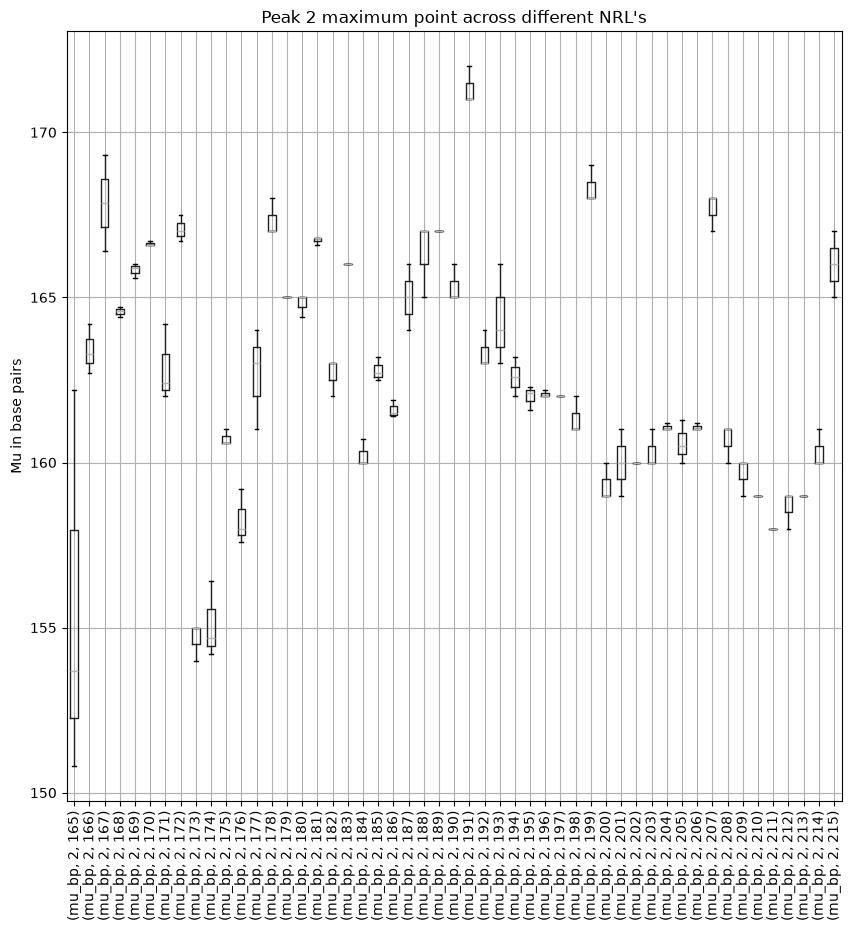

In [73]:
# make a new df with just the peak 3 and y_value data

new_peak2_df = pd.DataFrame(mu_values_peak_2)

new_peak2_df['y_value'] = plot_x_discrete_value

# now maybe pivot it 

# this pivot is for peak 3, mu_bp values, and the different nrl lengths as y_values
mu_peak2_nrls_for_boxplot = new_peak2_df.pivot( columns= 'y_value')

# fig, ax = plt.subplots()
# ax.plot(mu_peak3_nrls_for_boxplot)
# fig.set_size_inches(7,7)
mu_peak2_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
plt.xticks(rotation = 90 )
plt.title("Peak 2 maximum point across different NRL's")
plt.ylabel("Mu in base pairs")
plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_MU_peak2.pdf")
plt.show()
plt.close()

# plt.

# plt.box(mu_peak3_nrls_for_boxplot )

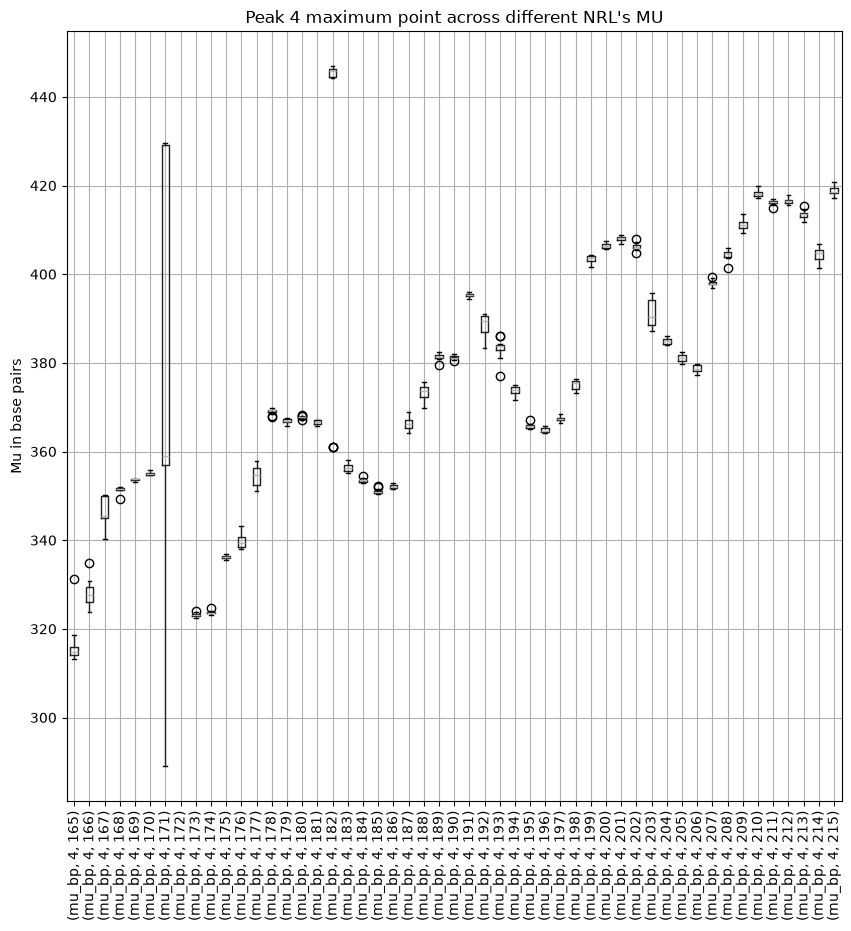

In [46]:
# make a new df with just the peak 3 and y_value data

new_peak4_df = pd.DataFrame(mu_values_peak_4)

new_peak4_df['y_value'] = plot_x_discrete_value

# now maybe pivot it 

# this pivot is for peak 3, mu_bp values, and the different nrl lengths as y_values
mu_peak4_nrls_for_boxplot = new_peak4_df.pivot( columns= 'y_value')

# fig, ax = plt.subplots()
# ax.plot(mu_peak3_nrls_for_boxplot)
# fig.set_size_inches(7,7)
mu_peak4_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
plt.xticks(rotation = 90 )
plt.title("Peak 4 maximum point across different NRL's MU")
plt.ylabel("Mu in base pairs")
plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_MU_peak4.pdf")
plt.show()
plt.close()

# plt.

# plt.box(mu_peak3_nrls_for_boxplot )

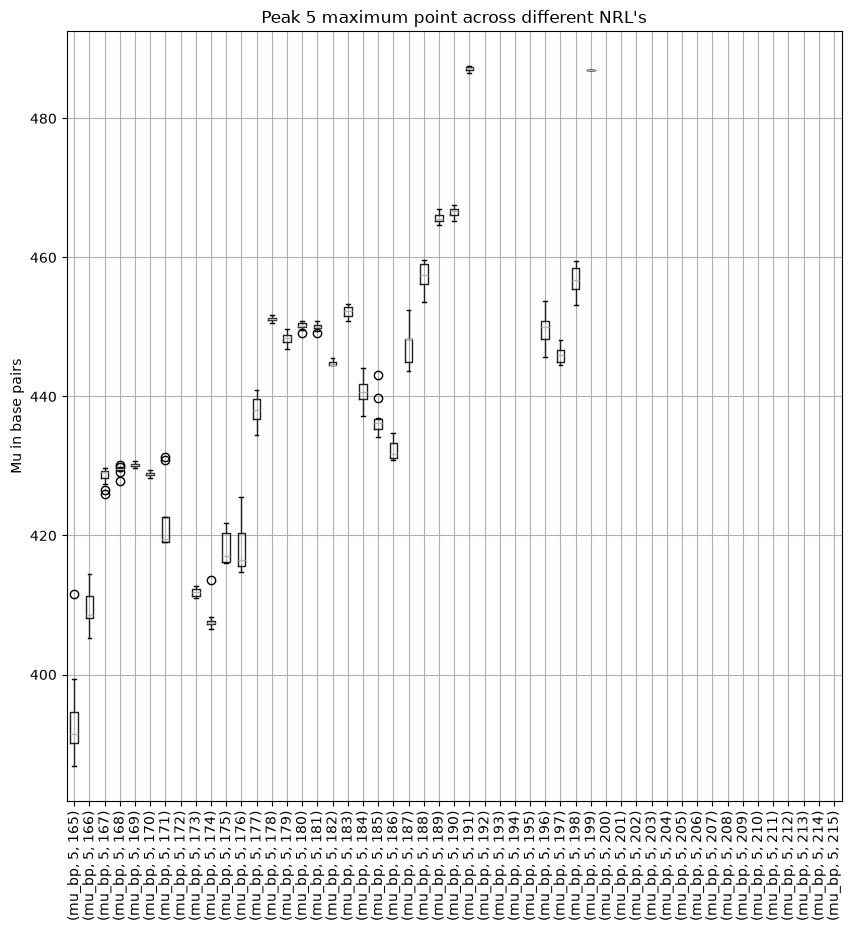

In [47]:
# make a new df with just the peak 3 and y_value data

new_peak5_df = pd.DataFrame(mu_values_peak_5)

new_peak5_df['y_value'] = plot_x_discrete_value

# now maybe pivot it 

# this pivot is for peak 3, mu_bp values, and the different nrl lengths as y_values
mu_peak5_nrls_for_boxplot = new_peak5_df.pivot( columns= 'y_value')

# fig, ax = plt.subplots()
# ax.plot(mu_peak3_nrls_for_boxplot)
# fig.set_size_inches(7,7)
mu_peak5_nrls_for_boxplot.boxplot(fontsize= 10, figsize=("10","10"))
plt.xticks(rotation = 90 )
plt.title("Peak 5 maximum point across different NRL's")
plt.ylabel("Mu in base pairs")
plt.savefig(fname="./all_nrl_165_to_215_results/boxplot_full_simulation_data_MU_peak5.pdf")
plt.show()
plt.close()

# plt.

# plt.box(mu_peak3_nrls_for_boxplot )

In [51]:
sigma_peak3_df[('sigma_bp',3)]

sample_name
NRL165_12nucs_2kbt_trial_1     22.8
NRL165_12nucs_2kbt_trial_10    19.6
NRL165_12nucs_2kbt_trial_11    19.3
NRL165_12nucs_2kbt_trial_12    20.2
NRL165_12nucs_2kbt_trial_13    19.4
                               ... 
NRL215_12nucs_2kbt_trial_5     10.0
NRL215_12nucs_2kbt_trial_6      8.7
NRL215_12nucs_2kbt_trial_7     10.4
NRL215_12nucs_2kbt_trial_8      8.5
NRL215_12nucs_2kbt_trial_9      8.3
Name: (sigma_bp, 3), Length: 765, dtype: float64

In [52]:
new_peak3_df[('mu_bp',3)]

sample_name
NRL165_12nucs_2kbt_trial_1     254.5
NRL165_12nucs_2kbt_trial_10    239.5
NRL165_12nucs_2kbt_trial_11    236.4
NRL165_12nucs_2kbt_trial_12    239.6
NRL165_12nucs_2kbt_trial_13    236.7
                               ...  
NRL215_12nucs_2kbt_trial_5     338.3
NRL215_12nucs_2kbt_trial_6     340.3
NRL215_12nucs_2kbt_trial_7     338.5
NRL215_12nucs_2kbt_trial_8     339.7
NRL215_12nucs_2kbt_trial_9     339.1
Name: (mu_bp, 3), Length: 765, dtype: float64

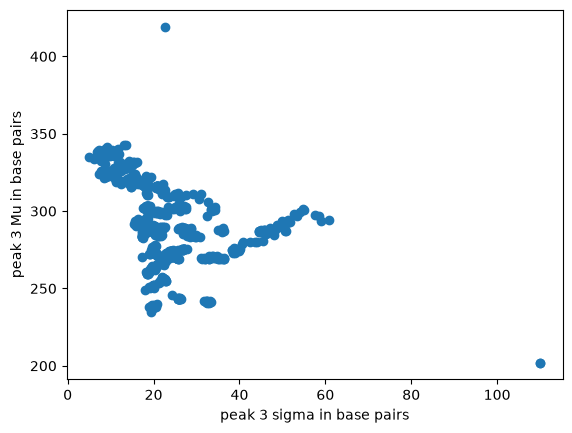

In [69]:
# let's try to make a scatter plot but instead of discrete values, we use a range from 150 to 250

x_axis_range = np.arange(150, 250)
x_axis_range

# plt.plot(mu_peak3_nrls_for_boxplot, mu_peak3_nrls_for_boxplot['y_value'])

# the 'y_value' here refers to what is used in machine learning data, NOT the y axis. This will acctually be the x axis
# plt.scatter( new_peak3_df['y_value'], new_peak3_df[('mu_bp',3)])
# plt.show()

plt.scatter( sigma_peak3_df[('sigma_bp',3)], new_peak3_df[('mu_bp',3)])
plt.xlabel("peak 3 sigma in base pairs")
plt.ylabel("peak 3 Mu in base pairs")
# plt.annotate()
plt.show()
plt.close()


# mu_peak3_nrls_for_boxplot

In [65]:
?plt.annotate

Signature:
plt.annotate(
    text: 'str',
    xy: 'tuple[Any, Any]',
    xytext: 'tuple[Any, Any] | None' = None,
    xycoords: 'CoordsType' = 'data',
    textcoords: 'CoordsType | None' = None,
    arrowprops: 'dict[str, Any] | None' = None,
    annotation_clip: 'bool | None' = None,
    **kwargs,
) -> 'Annotation'
Docstring:
Annotate the point *xy* with text *text*.

In the simplest form, the text is placed at *xy*.

Optionally, the text can be displayed in another position *xytext*.
An arrow pointing from the text to the annotated point *xy* can then
be added by defining *arrowprops*.

Parameters
----------
text : str
    The text of the annotation.

xy : (float, float)
    The point *(x, y)* to annotate. The coordinate system is determined
    by *xycoords*.

xytext : (float, float), default: *xy*
    The position *(x, y)* to place the text at. The coordinate system
    is determined by *textcoords*.

xycoords : single or two-tuple of str or `.Artist` or `.Transform` or callable, d

In [50]:
print("hi")

hi


In [63]:
# maybe i need to use scikit learn

from sklearn.linear_model import LinearRegression

In [64]:
new_peak3_df[[('mu_bp',3)]]

,mu_bp
component,3
sample_name,
NRL165_12nucs_2kbt_trial_1,254.5
NRL165_12nucs_2kbt_trial_10,239.5
NRL165_12nucs_2kbt_trial_3,236.9
NRL166_12nucs_2kbt_trial_1,248.9
NRL166_12nucs_2kbt_trial_10,257.7
...,...
NRL214_12nucs_2kbt_trial_10,325.5
NRL214_12nucs_2kbt_trial_3,330.6


In [75]:
# this is the best way to convert my data to integers
# needs a 2d array, so use the double brackets
# new_peak3_df[['y_value']].to_numpy().astype(int)
# new_peak3_df[[('mu_bp',3)]].to_numpy().astype(float)


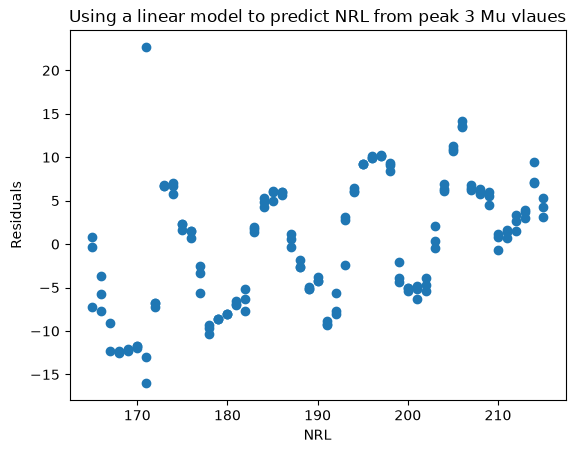

In [70]:

# split my data into X values and y values

y_axis_data = new_peak3_df[[('mu_bp',3)]].to_numpy().astype(float)

x_axis_data = new_peak3_df[['y_value']].to_numpy().astype(int)

# now use a linear model to predict
lin_model = LinearRegression()

lin_model.fit( y_axis_data, x_axis_data)

# now predict the y values from the model
# no i want to predict the x axis values from the y axis data
x_predict = lin_model.predict(y_axis_data)

# getting the residuals
res = x_axis_data - x_predict

# this is showing the x values (NRL) on the y axis. which represents the nrl for peaks 3
plt.scatter(x_axis_data, res)
plt.xlabel('NRL')
plt.ylabel('Residuals')
plt.title('Using a linear model to predict NRL from peak 3 Mu vlaues')
plt.savefig("./all_nrl_165_to_215_results/all_NRL_linear_residue_plot_peak3_mu.pdf")
plt.show()
plt.close()

# what i am doing here is training a linear model to predict NRL values from the y data which is the mu values of peak 3

# is this the right way?

# the closer you are to 0 the better you do at prediction, so this was poor prediction


In [66]:
# so now, i might have to try a polynomial model to see if it does a better job at predicting the NRL from mu
# it seems like a linear model is not great for this data

from sklearn.preprocessing import PolynomialFeatures


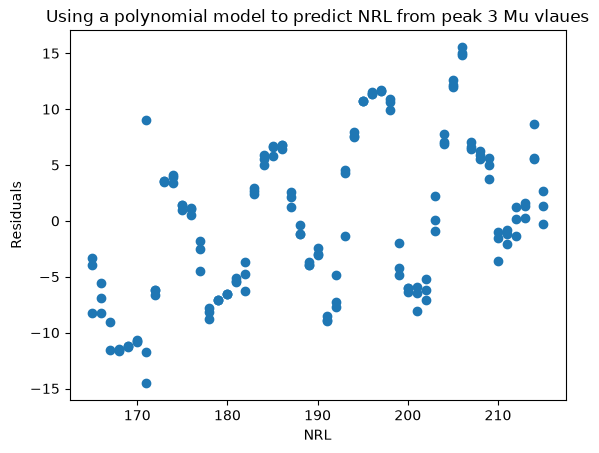

In [67]:
# 1. Transform your input data to allow a curve (degree 2 creates a parabola/U-shape)
poly = PolynomialFeatures(degree=2)
y_axis_data_poly = poly.fit_transform(y_axis_data)

# 2. Train the model using the curved features
poly_model = LinearRegression()
poly_model.fit(y_axis_data_poly, x_axis_data)

# 3. Predict and calculate the new residuals
x_predict_poly = poly_model.predict(y_axis_data_poly)
res_poly = x_axis_data - x_predict_poly

# 4. Plot the new residuals
plt.scatter(x_axis_data, res_poly)
plt.xlabel('NRL')
plt.ylabel('Residuals')
plt.title('Using a polynomial model to predict NRL from peak 3 Mu vlaues')
plt.show()

In [68]:
# now fitting a line to the data and getting the residual for each NRL on the graph

# can use seaborn for this

import seaborn as sns

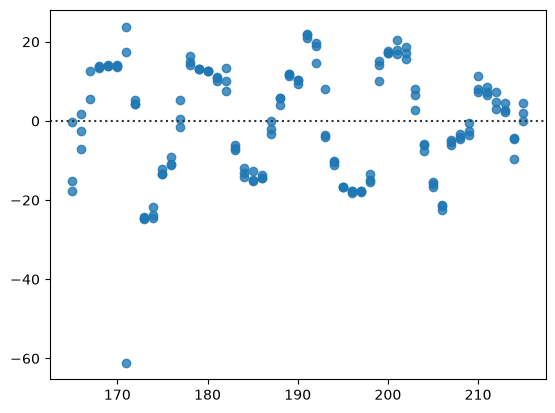

In [69]:
# okay, I used pip install seaborn to get the module into the conda enviornment for this notebook
# it loads fine

# just an easier way to do the linear residual plot from our mu and nrl data.

sns.residplot(x = x_axis_data, y = y_axis_data, order=2 )
plt.show()


In [41]:
?sns.residplot

Signature:
sns.residplot(
    data=None,
    *,
    x=None,
    y=None,
    x_partial=None,
    y_partial=None,
    lowess=False,
    order=1,
    robust=False,
    dropna=True,
    label=None,
    color=None,
    scatter_kws=None,
    line_kws=None,
    ax=None,
)
Docstring:
Plot the residuals of a linear regression.

This function will regress y on x (possibly as a robust or polynomial
regression) and then draw a scatterplot of the residuals. You can
optionally fit a lowess smoother to the residual plot, which can
help in determining if there is structure to the residuals.

Parameters
----------
data : DataFrame, optional
    DataFrame to use if `x` and `y` are column names.
x : vector or string
    Data or column name in `data` for the predictor variable.
y : vector or string
    Data or column name in `data` for the response variable.
{x, y}_partial : vectors or string(s) , optional
    These variables are treated as confounding and are removed from
    the `x` or `y` variables bef

In [30]:
# new_peak3_df['y_value']

sample_name
NRL165_12nucs_2kbt_trial_1     165
NRL165_12nucs_2kbt_trial_10    165
NRL165_12nucs_2kbt_trial_3     165
NRL166_12nucs_2kbt_trial_1     166
NRL166_12nucs_2kbt_trial_10    166
NRL166_12nucs_2kbt_trial_3     166
NRL167_12nucs_2kbt_trial_1     167
NRL167_12nucs_2kbt_trial_3     167
NRL168_12nucs_2kbt_trial_1     168
NRL168_12nucs_2kbt_trial_10    168
NRL168_12nucs_2kbt_trial_3     168
NRL178_12nucs_2kbt_trial_1     178
NRL178_12nucs_2kbt_trial_10    178
NRL178_12nucs_2kbt_trial_3     178
NRL215_12nucs_2kbt_trial_1     215
NRL215_12nucs_2kbt_trial_10    215
NRL215_12nucs_2kbt_trial_3     215
Name: y_value, dtype: str

In [121]:
?np.wilcoxon

# look for the residual when fitting a linear line to the data
# plot x axis in base pairs

Object `np.wilcoxon` not found.
